# Construcción paso a paso del dataset maestro OULAD

Este Notebook documenta cómo se construye `maestro.csv` conservando siempre la granularidad:

```python
KEYS = ["id_student", "code_module", "code_presentation"]
```

La secuencia es:

```text
studentVle + vle ──► interacciones agregadas y pivotadas ┐
                                                          ├─► studentInfo ─► objetivo y nulos ─► maestro.csv
studentAssessment + assessments ──► notas y retrasos ────┘
```

Los `merge` utilizan validaciones de cardinalidad y se comprueba que ninguna integración duplique estudiantes, módulos o presentaciones.

## 1. Configuración y archivos requeridos

In [1]:
from pathlib import Path
import re
import sys
import subprocess

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

DATA_PATH = Path("./data/")
OUTPUT_PATH = DATA_PATH / "maestro.csv"
RANDOM_STATE = 42
KAGGLE_DATASET = "anlgrbz/student-demographics-online-education-dataoulad"
KAGGLE_URL = f"https://www.kaggle.com/datasets/{KAGGLE_DATASET}"
KEYS = ["id_student", "code_module", "code_presentation"]
REQUIRED_FILES = [
    "studentInfo.csv", "studentVle.csv", "vle.csv",
    "studentAssessment.csv", "assessments.csv"
]

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 100)
DATA_PATH.mkdir(parents=True, exist_ok=True)

# Descarga automática del paquete completo cuando falta algún CSV requerido.
available_csv = {file.name: file for file in DATA_PATH.rglob("*.csv")}
missing_files = [name for name in REQUIRED_FILES if name not in available_csv]

if missing_files:
    print("Faltan archivos OULAD:", missing_files)
    print("Descargando desde:", KAGGLE_URL)
    try:
        try:
            import kagglehub
        except ImportError:
            print("Instalando kagglehub...")
            subprocess.check_call([
                sys.executable, "-m", "pip", "install", "-q", "kagglehub"
            ])
            import kagglehub

        downloaded_path = kagglehub.dataset_download(
            KAGGLE_DATASET,
            output_dir=str(DATA_PATH),
        )
        print("Descarga completada en:", downloaded_path)
    except Exception as exc:
        raise RuntimeError(
            "No fue posible descargar OULAD desde Kaggle. Verifique la conexión. "
            "Si Kaggle solicita autenticación, ejecute `kaggle auth login` o "
            "configure un token desde https://www.kaggle.com/settings/api."
        ) from exc

    available_csv = {file.name: file for file in DATA_PATH.rglob("*.csv")}
    missing_files = [name for name in REQUIRED_FILES if name not in available_csv]
    if missing_files:
        raise FileNotFoundError(
            f"La descarga terminó, pero todavía faltan archivos: {missing_files}"
        )
else:
    print("Los archivos OULAD ya existen; no se repite la descarga.")

print("Directorio de datos:", DATA_PATH.resolve())
print("Fuente Kaggle:", KAGGLE_URL)
print("CSV disponibles:", sorted(available_csv))
print("Archivo de salida:", OUTPUT_PATH.resolve())

Los archivos OULAD ya existen; no se repite la descarga.
Directorio de datos: C:\Users\jllr3\Documents\IA\AprendizajeAutomatico\TallerPractico3\data
Fuente Kaggle: https://www.kaggle.com/datasets/anlgrbz/student-demographics-online-education-dataoulad
CSV disponibles: ['acciones_por_senal_shap.csv', 'assessments.csv', 'courses.csv', 'importancia_shap_global.csv', 'importancia_xgboost_gain.csv', 'incidencias_calidad.csv', 'maestro.csv', 'maestro_clusters.csv', 'maestro_limpio.csv', 'metricas_clustering.csv', 'metricas_modelos.csv', 'metricas_threshold.csv', 'outliers_revision.csv', 'pca_loadings.csv', 'pca_varianza.csv', 'perfiles_clusters.csv', 'plan_intervencion_riesgo.csv', 'predicciones_test.csv', 'recomendaciones_locales_shap.csv', 'recomendaciones_por_cuadro.csv', 'reporte_calidad_campos.csv', 'studentAssessment.csv', 'studentInfo.csv', 'studentVle.csv', 'tsne_visualizacion.csv', 'vle.csv']
Archivo de salida: C:\Users\jllr3\Documents\IA\AprendizajeAutomatico\TallerPractico3\data\m

### Descarga automática

Si falta algún archivo, se descarga el paquete público completo desde Kaggle. Si los archivos ya existen, la descarga no se repite.

In [2]:
def discover_csv(path):
    return {file.name: file for file in path.rglob("*.csv")}


def ensure_oulad_files(path, required):
    path.mkdir(parents=True, exist_ok=True)
    found = discover_csv(path)
    missing = [name for name in required if name not in found]
    if not missing:
        print("Todos los CSV requeridos ya están disponibles.")
        return found

    print("Archivos faltantes:", missing)
    try:
        import kagglehub
    except ImportError:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "kagglehub"])
        import kagglehub

    downloaded = kagglehub.dataset_download(KAGGLE_DATASET, output_dir=str(path))
    print("Descarga completada:", downloaded)
    found = discover_csv(path)
    missing = [name for name in required if name not in found]
    if missing:
        raise FileNotFoundError(f"Después de descargar todavía faltan: {missing}")
    return found


available_csv = ensure_oulad_files(DATA_PATH, REQUIRED_FILES)
pd.DataFrame({
    "archivo": sorted(available_csv),
    "tamaño_MB": [available_csv[name].stat().st_size / 1024**2 for name in sorted(available_csv)]
}).round(2)

Todos los CSV requeridos ya están disponibles.


,archivo,tamaño_MB
0,acciones_por_senal_shap.csv,0.00
1,assessments.csv,0.01
2,courses.csv,0.00
3,importancia_shap_global.csv,0.00
4,importancia_xgboost_gain.csv,0.00
5,incidencias_calidad.csv,0.01
6,maestro.csv,9.52
7,maestro_clusters.csv,9.50
8,maestro_limpio.csv,7.91
9,metricas_clustering.csv,0.00


## 2. Funciones de validación

In [3]:
def require_columns(frame, columns, name):
    missing = sorted(set(columns) - set(frame.columns))
    if missing:
        raise KeyError(f"{name}: faltan columnas {missing}")


def assert_unique_key(frame, name):
    missing_key = int(frame[KEYS].isna().any(axis=1).sum())
    duplicates = int(frame.duplicated(KEYS).sum())
    print(f"{name}: filas={len(frame):,}, llaves nulas={missing_key}, duplicadas={duplicates}")
    assert missing_key == 0, f"{name} contiene llaves incompletas"
    assert duplicates == 0, f"{name} no es único por {KEYS}"


def compact_audit(frame, name):
    return {
        "dataset": name,
        "filas": len(frame),
        "columnas": frame.shape[1],
        "duplicados_fila": int(frame.duplicated().sum()),
        "celdas_nulas_pct": round(frame.isna().mean().mean() * 100, 2),
    }

## 3. Carga y auditoría inicial

Para `studentVle.csv` se cargan solo las columnas necesarias, reduciendo el uso de memoria sin alterar el resultado.

In [4]:
student_info = pd.read_csv(available_csv["studentInfo.csv"])
vle_catalog = pd.read_csv(available_csv["vle.csv"])
student_vle = pd.read_csv(
    available_csv["studentVle.csv"],
    usecols=KEYS + ["id_site", "date", "sum_click"]
)
assessments = pd.read_csv(available_csv["assessments.csv"])
student_assessment = pd.read_csv(available_csv["studentAssessment.csv"])

audits = pd.DataFrame([
    compact_audit(student_info, "studentInfo"),
    compact_audit(vle_catalog, "vle"),
    compact_audit(student_vle, "studentVle"),
    compact_audit(assessments, "assessments"),
    compact_audit(student_assessment, "studentAssessment"),
])
display(audits)
assert_unique_key(student_info, "studentInfo")
display(student_info.head())

,dataset,filas,columnas,duplicados_fila,celdas_nulas_pct
0,studentInfo,32593,12,0,0.28
1,vle,6364,6,0,27.46
2,studentVle,10655280,6,787170,0.00
3,assessments,206,6,0,0.89
4,studentAssessment,173912,5,0,0.02


studentInfo: filas=32,593, llaves nulas=0, duplicadas=0


,code_module,code_presentation,id_student,gender,region,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,disability,final_result
0,AAA,2013J,11391,M,East Anglian Region,HE Qualification,90-100%,55<=,0,240,N,Pass
1,AAA,2013J,28400,F,Scotland,HE Qualification,20-30%,35-55,0,60,N,Pass
2,AAA,2013J,30268,F,North Western Region,A Level or Equivalent,30-40%,35-55,0,60,Y,Withdrawn
3,AAA,2013J,31604,F,South East Region,A Level or Equivalent,50-60%,35-55,0,60,N,Pass
4,AAA,2013J,32885,F,West Midlands Region,Lower Than A Level,50-60%,0-35,0,60,N,Pass


## 4. Interacciones digitales: `studentVle` + `vle`

El catálogo aporta `activity_type`. El cruce se valida como `many_to_one` porque muchos eventos pueden apuntar al mismo recurso. Luego se agregan clics, días activos y sitios por la llave compuesta; finalmente se pivota la suma de clics por actividad.

In [5]:
vle_join_keys = ["id_site", "code_module", "code_presentation"]
require_columns(student_vle, KEYS + ["id_site", "date", "sum_click"], "studentVle")
require_columns(vle_catalog, vle_join_keys + ["activity_type"], "vle")
assert not vle_catalog.duplicated(vle_join_keys).any()

vle_events = student_vle.merge(
    vle_catalog[vle_join_keys + ["activity_type"]],
    on=vle_join_keys,
    how="left",
    validate="many_to_one",
    indicator=True,
)
vle_match_rate = vle_events["_merge"].eq("both").mean()
print(f"Coincidencia con catálogo VLE: {vle_match_rate:.2%}")
display(vle_events["_merge"].value_counts().to_frame("eventos"))
vle_events["activity_type"] = vle_events["activity_type"].fillna("unknown")
vle_events = vle_events.drop(columns="_merge")

Coincidencia con catálogo VLE: 100.00%


,eventos
_merge,
both,10655280
left_only,0
right_only,0


In [6]:
vle_base = (
    vle_events.groupby(KEYS, as_index=False)
    .agg(
        total_clicks=("sum_click", "sum"),
        active_days=("date", "nunique"),
        num_sites_used=("id_site", "nunique"),
    )
)

vle_pivot = pd.pivot_table(
    vle_events,
    index=KEYS,
    columns="activity_type",
    values="sum_click",
    aggfunc="sum",
    fill_value=0,
)
vle_pivot.columns = [
    "clicks_" + re.sub(r"[^0-9a-zA-Z]+", "_", str(value).lower()).strip("_")
    for value in vle_pivot.columns
]
vle_agg = vle_base.merge(vle_pivot.reset_index(), on=KEYS, how="left", validate="one_to_one")
active = vle_agg["active_days"].to_numpy(dtype=float)
clicks = vle_agg["total_clicks"].to_numpy(dtype=float)
vle_agg["clicks_per_active_day"] = np.divide(
    clicks, active, out=np.zeros(len(vle_agg)), where=active != 0
)
assert_unique_key(vle_agg, "VLE agregado")
click_columns = [column for column in vle_agg if column.startswith("clicks_")]
print("Columnas de actividad generadas:", click_columns)
display(vle_agg.head())

VLE agregado: filas=29,228, llaves nulas=0, duplicadas=0
Columnas de actividad generadas: ['clicks_dataplus', 'clicks_dualpane', 'clicks_externalquiz', 'clicks_folder', 'clicks_forumng', 'clicks_glossary', 'clicks_homepage', 'clicks_htmlactivity', 'clicks_oucollaborate', 'clicks_oucontent', 'clicks_ouelluminate', 'clicks_ouwiki', 'clicks_page', 'clicks_questionnaire', 'clicks_quiz', 'clicks_repeatactivity', 'clicks_resource', 'clicks_sharedsubpage', 'clicks_subpage', 'clicks_url', 'clicks_per_active_day']


,id_student,code_module,code_presentation,total_clicks,active_days,num_sites_used,clicks_dataplus,clicks_dualpane,clicks_externalquiz,clicks_folder,clicks_forumng,clicks_glossary,clicks_homepage,clicks_htmlactivity,clicks_oucollaborate,clicks_oucontent,clicks_ouelluminate,clicks_ouwiki,clicks_page,clicks_questionnaire,clicks_quiz,clicks_repeatactivity,clicks_resource,clicks_sharedsubpage,clicks_subpage,clicks_url,clicks_per_active_day
0,6516,AAA,2014J,2791,159,84,21,0,0,0,451,0,497,0,0,1505,0,0,0,0,0,0,31,0,143,143,17.553459
1,8462,DDD,2013J,646,56,125,0,0,12,0,36,0,184,0,12,64,0,18,0,0,0,0,70,0,227,23,11.535714
2,8462,DDD,2014J,10,1,3,0,0,0,0,2,0,7,0,1,0,0,0,0,0,0,0,0,0,0,0,10.000000
3,11391,AAA,2013J,934,40,55,0,0,0,0,193,0,138,0,0,553,0,0,0,0,0,0,13,0,32,5,23.350000
4,23629,BBB,2013B,161,16,11,0,0,0,0,87,0,36,0,0,0,0,0,0,0,31,0,2,0,5,0,10.062500


## 5. Evaluaciones: `studentAssessment` + `assessments`

`assessments.csv` aporta módulo, presentación y fecha límite. Se define `delay_days = date_submitted - date`: valores positivos indican retraso. Cuando no existe fecha límite, el retraso permanece desconocido.

In [7]:
require_columns(student_assessment, ["id_assessment", "id_student", "date_submitted", "score"], "studentAssessment")
require_columns(assessments, ["id_assessment", "code_module", "code_presentation", "date"], "assessments")
assert not assessments.duplicated("id_assessment").any()

assessment_events = student_assessment.merge(
    assessments[["id_assessment", "code_module", "code_presentation", "date"]],
    on="id_assessment",
    how="left",
    validate="many_to_one",
    indicator=True,
)
assessment_match_rate = assessment_events["_merge"].eq("both").mean()
print(f"Coincidencia con catálogo de evaluaciones: {assessment_match_rate:.2%}")
assessment_events = assessment_events.drop(columns="_merge")
assessment_events["delay_days"] = assessment_events["date_submitted"] - assessment_events["date"]
assessment_events["is_late"] = np.where(
    assessment_events["date"].notna(),
    assessment_events["delay_days"].gt(0).astype(float),
    np.nan,
)
display(assessment_events.head())

Coincidencia con catálogo de evaluaciones: 100.00%

,id_assessment,id_student,date_submitted,is_banked,score,code_module,code_presentation,date,delay_days,is_late
0,1752,11391,18,0,78.0,AAA,2013J,19.0,-1.0,0.0
1,1752,28400,22,0,70.0,AAA,2013J,19.0,3.0,1.0
2,1752,31604,17,0,72.0,AAA,2013J,19.0,-2.0,0.0
3,1752,32885,26,0,69.0,AAA,2013J,19.0,7.0,1.0
4,1752,38053,19,0,79.0,AAA,2013J,19.0,0.0,0.0


In [8]:
assessment_agg = (
    assessment_events.groupby(KEYS, as_index=False)
    .agg(
        avg_score=("score", "mean"), median_score=("score", "median"),
        std_score=("score", "std"), min_score=("score", "min"), max_score=("score", "max"),
        num_assessments=("id_assessment", "nunique"),
        num_submitted_assessments=("date_submitted", "count"),
        avg_delay_days=("delay_days", "mean"), max_delay_days=("delay_days", "max"),
        late_submissions=("is_late", "sum"), dated_assessments=("is_late", "count"),
    )
)
late = assessment_agg["late_submissions"].to_numpy(dtype=float)
dated = assessment_agg["dated_assessments"].to_numpy(dtype=float)
assessment_agg["late_submission_rate"] = np.divide(
    late, dated, out=np.full(len(assessment_agg), np.nan), where=dated != 0
)
assessment_agg = assessment_agg.drop(columns="dated_assessments")
assert_unique_key(assessment_agg, "Evaluaciones agregadas")
display(assessment_agg.head())

Evaluaciones agregadas: filas=25,843, llaves nulas=0, duplicadas=0


,id_student,code_module,code_presentation,avg_score,median_score,std_score,min_score,max_score,num_assessments,num_submitted_assessments,avg_delay_days,max_delay_days,late_submissions,late_submission_rate
0,6516,AAA,2014J,61.800000,61.0,10.329569,48.0,77.0,5,5,-2.600000,-1.0,0.0,0.000000
1,8462,DDD,2013J,87.666667,87.0,5.033223,83.0,93.0,3,3,-0.333333,4.0,1.0,0.333333
2,8462,DDD,2014J,86.500000,85.0,4.725816,83.0,93.0,4,4,-59.500000,-21.0,0.0,0.000000
3,11391,AAA,2013J,82.000000,82.0,3.082207,78.0,85.0,5,5,-1.800000,-1.0,0.0,0.000000
4,23629,BBB,2013B,82.500000,83.5,20.273135,63.0,100.0,4,4,3.500000,12.0,3.0,0.750000


## 6. Integración con la base demográfica

`studentInfo` define el universo. Por eso se realizan dos `LEFT JOIN`: estudiantes sin eventos VLE o evaluaciones deben permanecer en el maestro. Cada unión usa `validate="one_to_one"` y debe conservar exactamente 32.593 filas.

In [9]:
base_rows = len(student_info)
maestro = student_info.merge(
    vle_agg, on=KEYS, how="left", validate="one_to_one", indicator="vle_merge"
)
maestro["has_vle_records"] = maestro["vle_merge"].eq("both").astype("int8")
vle_coverage = maestro["has_vle_records"].mean()
maestro = maestro.drop(columns="vle_merge")
assert len(maestro) == base_rows
assert_unique_key(maestro, "Después del merge VLE")

maestro = maestro.merge(
    assessment_agg, on=KEYS, how="left", validate="one_to_one", indicator="assessment_merge"
)
maestro["has_assessment_records"] = maestro["assessment_merge"].eq("both").astype("int8")
assessment_coverage = maestro["has_assessment_records"].mean()
maestro = maestro.drop(columns="assessment_merge")
assert len(maestro) == base_rows
assert_unique_key(maestro, "Después del merge de evaluaciones")

pd.DataFrame({
    "fuente": ["VLE", "Evaluaciones"],
    "cobertura": [vle_coverage, assessment_coverage],
    "sin_registros": [(maestro.has_vle_records == 0).sum(),
                       (maestro.has_assessment_records == 0).sum()]
})

Después del merge VLE: filas=32,593, llaves nulas=0, duplicadas=0


Después del merge de evaluaciones: filas=32,593, llaves nulas=0, duplicadas=0


,fuente,cobertura,sin_registros
0,VLE,0.896757,3365
1,Evaluaciones,0.792900,6750


## 7. Variable objetivo y valores nulos

`Withdrawn` se transforma en 1; Pass, Fail y Distinction en 0. `final_result` se conserva para descripción, pero no debe usarse como predictor.

La ausencia de eventos VLE y de conteos de entregas se representa con cero porque significa actividad no registrada. En cambio, promedios, dispersión de notas y retrasos desconocidos permanecen `NaN`; deberán imputarse dentro del pipeline de modelado para evitar fuga de información.

In [10]:
maestro["target_withdrawn"] = maestro["final_result"].eq("Withdrawn").astype("int8")

activity_zero_columns = [column for column in maestro if column.startswith("clicks_")]
activity_zero_columns += ["total_clicks", "active_days", "num_sites_used"]
activity_zero_columns = list(dict.fromkeys(column for column in activity_zero_columns if column in maestro))
maestro[activity_zero_columns] = maestro[activity_zero_columns].fillna(0)

assessment_zero_columns = ["num_assessments", "num_submitted_assessments", "late_submissions"]
maestro[assessment_zero_columns] = maestro[assessment_zero_columns].fillna(0)

categorical_columns = [
    column for column in ["gender", "region", "highest_education", "imd_band", "age_band", "disability"]
    if column in maestro
]
maestro[categorical_columns] = maestro[categorical_columns].fillna("Unknown")
maestro["log_total_clicks"] = np.log1p(maestro["total_clicks"])
maestro["log_active_days"] = np.log1p(maestro["active_days"])

target_summary = (
    maestro.groupby("final_result")["target_withdrawn"]
    .agg(observaciones="size", objetivo_promedio="mean")
)
display(target_summary)
print(f"Tasa total de abandono: {maestro.target_withdrawn.mean():.2%}")

,observaciones,objetivo_promedio
final_result,,
Distinction,3024,0.0
Fail,7052,0.0
Pass,12361,0.0
Withdrawn,10156,1.0


Tasa total de abandono: 31.16%


,valores_nulos
std_score,9292
median_score,6773
min_score,6773
avg_score,6773
max_score,6773
max_delay_days,6751
avg_delay_days,6751
late_submission_rate,6751


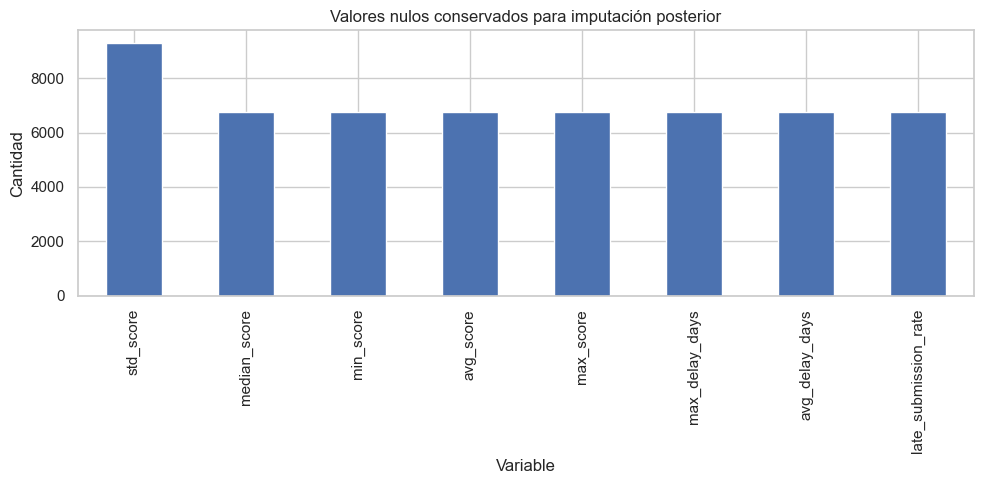

In [11]:
missing_summary = maestro.isna().sum().sort_values(ascending=False)
display(missing_summary[missing_summary > 0].to_frame("valores_nulos"))

plt.figure(figsize=(10, 5))
missing_summary[missing_summary > 0].plot(kind="bar")
plt.title("Valores nulos conservados para imputación posterior")
plt.xlabel("Variable"); plt.ylabel("Cantidad")
plt.tight_layout(); plt.show()

## 8. Validación final y exportación de `maestro.csv`

In [12]:
assert len(maestro) == len(student_info)
assert_unique_key(maestro, "Maestro final")
assert maestro["target_withdrawn"].isin([0, 1]).all()
assert maestro["target_withdrawn"].eq(maestro["final_result"].eq("Withdrawn").astype(int)).all()
assert not maestro[activity_zero_columns].isna().any().any()

maestro = maestro.sort_values(KEYS, kind="stable").reset_index(drop=True)
maestro.to_csv(OUTPUT_PATH, index=False, encoding="utf-8-sig")

verification = pd.read_csv(OUTPUT_PATH, low_memory=False)
assert verification.shape == maestro.shape
assert not verification.duplicated(KEYS).any()

print("Archivo creado:", OUTPUT_PATH.resolve())
print(f"Dimensiones: {maestro.shape[0]:,} filas x {maestro.shape[1]} columnas")
print("Duplicados por llave:", maestro.duplicated(KEYS).sum())
print(f"Tamaño: {OUTPUT_PATH.stat().st_size / 1024**2:.2f} MB")
display(maestro.head())

Maestro final: filas=32,593, llaves nulas=0, duplicadas=0


Archivo creado: C:\Users\jllr3\Documents\IA\AprendizajeAutomatico\TallerPractico3\data\maestro.csv
Dimensiones: 32,593 filas x 52 columnas
Duplicados por llave: 0
Tamaño: 9.52 MB


,code_module,code_presentation,id_student,gender,region,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,disability,final_result,total_clicks,active_days,num_sites_used,clicks_dataplus,clicks_dualpane,clicks_externalquiz,clicks_folder,clicks_forumng,clicks_glossary,clicks_homepage,clicks_htmlactivity,clicks_oucollaborate,clicks_oucontent,clicks_ouelluminate,clicks_ouwiki,clicks_page,clicks_questionnaire,clicks_quiz,clicks_repeatactivity,clicks_resource,clicks_sharedsubpage,clicks_subpage,clicks_url,clicks_per_active_day,has_vle_records,avg_score,median_score,std_score,min_score,max_score,num_assessments,num_submitted_assessments,avg_delay_days,max_delay_days,late_submissions,late_submission_rate,has_assessment_records,target_withdrawn,log_total_clicks,log_active_days
0,DDD,2013J,3733,M,South Region,HE Qualification,90-100%,55<=,0,60,N,Withdrawn,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0,NaN,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN,0.0,NaN,0,1,0.000000,0.000000
1,AAA,2014J,6516,M,Scotland,HE Qualification,80-90%,55<=,0,60,N,Pass,2791.0,159.0,84.0,21.0,0.0,0.0,0.0,451.0,0.0,497.0,0.0,0.0,1505.0,0.0,0.0,0.0,0.0,0.0,0.0,31.0,0.0,143.0,143.0,17.553459,1,61.800000,61.0,10.329569,48.0,77.0,5.0,5.0,-2.600000,-1.0,0.0,0.000000,1,0,7.934513,5.075174
2,DDD,2013J,8462,M,London Region,HE Qualification,30-40%,55<=,0,90,N,Withdrawn,646.0,56.0,125.0,0.0,0.0,12.0,0.0,36.0,0.0,184.0,0.0,12.0,64.0,0.0,18.0,0.0,0.0,0.0,0.0,70.0,0.0,227.0,23.0,11.535714,1,87.666667,87.0,5.033223,83.0,93.0,3.0,3.0,-0.333333,4.0,1.0,0.333333,1,1,6.472346,4.043051
3,DDD,2014J,8462,M,London Region,HE Qualification,30-40%,55<=,1,60,N,Withdrawn,10.0,1.0,3.0,0.0,0.0,0.0,0.0,2.0,0.0,7.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,10.000000,1,86.500000,85.0,4.725816,83.0,93.0,4.0,4.0,-59.500000,-21.0,0.0,0.000000,1,1,2.397895,0.693147
4,AAA,2013J,11391,M,East Anglian Region,HE Qualification,90-100%,55<=,0,240,N,Pass,934.0,40.0,55.0,0.0,0.0,0.0,0.0,193.0,0.0,138.0,0.0,0.0,553.0,0.0,0.0,0.0,0.0,0.0,0.0,13.0,0.0,32.0,5.0,23.350000,1,82.000000,82.0,3.082207,78.0,85.0,5.0,5.0,-1.800000,-1.0,0.0,0.000000,1,0,6.840547,3.713572


## 9. Resultado de la construcción

El archivo final mantiene una fila por estudiante, módulo y presentación. Las columnas `has_vle_records` y `has_assessment_records` permiten distinguir ausencia real de registros frente a valores desconocidos. `final_result` solo debe emplearse en análisis descriptivo; para modelado se utiliza `target_withdrawn` y se excluye `final_result` para prevenir fuga directa.

## 10. Calidad de datos basada en DAMA

La calidad se evalúa campo por campo mediante dimensiones habitualmente utilizadas en gobierno de datos:

- **Completitud:** presencia de los datos requeridos.
- **Unicidad:** ausencia de duplicados en la llave de negocio.
- **Validez:** cumplimiento de tipo, formato, dominio y rango.
- **Consistencia:** coherencia entre campos relacionados.
- **Integridad:** relaciones correctas entre fuentes y catálogos.
- **Oportunidad temporal:** interpretación correcta de periodos y días relativos.
- **Exactitud:** correspondencia con la realidad. Esta dimensión no puede certificarse únicamente con el archivo; requiere contraste con una fuente autorizada.

La limpieza es deliberadamente **no destructiva**: los valores extremos se señalan para revisión y no se eliminan automáticamente. El maestro original se conserva y el resultado limpio se exporta como `maestro_limpio.csv`.

## 11. Perfil de calidad antes de limpiar

In [13]:
def profile_fields(frame):
    rows = []
    for column in frame.columns:
        series = frame[column]
        row = {
            "campo": column,
            "tipo_actual": str(series.dtype),
            "filas": len(series),
            "nulos": int(series.isna().sum()),
            "nulos_pct": round(series.isna().mean() * 100, 3),
            "valores_unicos": int(series.nunique(dropna=True)),
        }
        if pd.api.types.is_numeric_dtype(series):
            row["minimo"] = series.min(skipna=True)
            row["maximo"] = series.max(skipna=True)
        else:
            row["minimo"] = np.nan
            row["maximo"] = np.nan
        rows.append(row)
    return pd.DataFrame(rows)


perfil_antes = profile_fields(maestro)
display(perfil_antes)

,campo,tipo_actual,filas,nulos,nulos_pct,valores_unicos,minimo,maximo
0,code_module,object,32593,0,0.000,7,NaN,NaN
1,code_presentation,object,32593,0,0.000,4,NaN,NaN
2,id_student,int64,32593,0,0.000,28785,3733.0,2.716795e+06
3,gender,object,32593,0,0.000,2,NaN,NaN
4,region,object,32593,0,0.000,13,NaN,NaN
5,highest_education,object,32593,0,0.000,5,NaN,NaN
6,imd_band,object,32593,0,0.000,11,NaN,NaN
7,age_band,object,32593,0,0.000,3,NaN,NaN
8,num_of_prev_attempts,int64,32593,0,0.000,7,0.0,6.000000e+00
9,studied_credits,int64,32593,0,0.000,61,30.0,6.550000e+02


## 12. Diccionario y reglas campo por campo

Las reglas se asignan por familias con significado homogéneo. Las columnas dinámicas `clicks_*` heredan la misma regla: conteos enteros no negativos. Los nulos académicos son admisibles cuando no existe una evaluación registrada; no se sustituyen por cero porque cero sería una calificación real.

In [14]:
click_activity_columns = [
    column for column in maestro.columns
    if column.startswith("clicks_") and column != "clicks_per_active_day"
]
count_columns = click_activity_columns + [
    "total_clicks", "active_days", "num_sites_used", "num_of_prev_attempts",
    "studied_credits", "num_assessments", "num_submitted_assessments", "late_submissions"
]
score_columns = ["avg_score", "median_score", "std_score", "min_score", "max_score"]
delay_columns = ["avg_delay_days", "max_delay_days"]
binary_columns = ["has_vle_records", "has_assessment_records", "target_withdrawn"]
categorical_columns = [
    "code_module", "code_presentation", "gender", "region", "highest_education",
    "imd_band", "age_band", "disability", "final_result"
]

rules = []
for column in maestro.columns:
    if column == "id_student":
        family, expected, nullable, rule = "Llave", "entero positivo", False, "id_student > 0"
    elif column in ["code_module", "code_presentation"]:
        family, expected, nullable, rule = "Llave", "categoría", False, "dominio oficial y formato válido"
    elif column in click_activity_columns:
        family, expected, nullable, rule = "Interacción VLE", "entero >= 0", False, "conteo no negativo"
    elif column in count_columns:
        family, expected, nullable, rule = "Conteo", "entero >= 0", False, "conteo no negativo"
    elif column in score_columns:
        family, expected, nullable, rule = "Evaluación", "decimal", True, "0–100; std_score >= 0"
    elif column in delay_columns:
        family, expected, nullable, rule = "Temporal relativo", "días decimales", True, "negativo=anticipada; positivo=tardía"
    elif column == "late_submission_rate":
        family, expected, nullable, rule = "Evaluación", "proporción", True, "0 <= tasa <= 1"
    elif column in binary_columns:
        family, expected, nullable, rule = "Indicador", "binario", False, "valor en {0,1}"
    elif column in ["log_total_clicks", "log_active_days"]:
        family, expected, nullable, rule = "Derivada", "decimal >= 0", False, "igual a log1p(variable original)"
    elif column == "clicks_per_active_day":
        family, expected, nullable, rule = "Derivada", "decimal >= 0", False, "total_clicks / active_days; 0 si no hay días"
    elif column in categorical_columns:
        family, expected, nullable, rule = "Categórica", "categoría", False, "dominio controlado; sin espacios laterales"
    else:
        family, expected, nullable, rule = "Demográfica", "según fuente", False, "dominio y tipo de studentInfo"
    rules.append({"campo": column, "familia": family, "tipo_esperado": expected,
                  "nulo_permitido": nullable, "regla_principal": rule})

diccionario_calidad = pd.DataFrame(rules)
display(diccionario_calidad)

,campo,familia,tipo_esperado,nulo_permitido,regla_principal
0,code_module,Llave,categoría,False,dominio oficial y formato válido
1,code_presentation,Llave,categoría,False,dominio oficial y formato válido
2,id_student,Llave,entero positivo,False,id_student > 0
3,gender,Categórica,categoría,False,dominio controlado; sin espacios laterales
4,region,Categórica,categoría,False,dominio controlado; sin espacios laterales
5,highest_education,Categórica,categoría,False,dominio controlado; sin espacios laterales
6,imd_band,Categórica,categoría,False,dominio controlado; sin espacios laterales
7,age_band,Categórica,categoría,False,dominio controlado; sin espacios laterales
8,num_of_prev_attempts,Conteo,entero >= 0,False,conteo no negativo
9,studied_credits,Conteo,entero >= 0,False,conteo no negativo


## 13. Registro de incidencias: llaves, dominios y formatos

In [15]:
quality_issues = []


def register_issue(field, dimension, rule, mask, severity, action):
    mask = pd.Series(mask, index=maestro.index).fillna(False)
    quality_issues.append({
        "campo": field,
        "dimension_DAMA": dimension,
        "regla": rule,
        "severidad": severity,
        "filas_afectadas": int(mask.sum()),
        "porcentaje": round(mask.mean() * 100, 4),
        "accion": action,
    })


register_issue("KEYS", "Unicidad", "Llave compuesta no duplicada",
               maestro.duplicated(KEYS, keep=False), "Crítica", "Bloquear publicación")
register_issue("KEYS", "Completitud", "Llave compuesta completa",
               maestro[KEYS].isna().any(axis=1), "Crítica", "Bloquear publicación")
register_issue("id_student", "Validez", "Identificador entero positivo",
               maestro["id_student"].le(0) | maestro["id_student"].isna(), "Crítica", "Corregir con fuente")

domain_rules = {
    "code_module": set(vle_catalog["code_module"].dropna().astype(str)),
    "code_presentation": set(vle_catalog["code_presentation"].dropna().astype(str)),
    "gender": {"M", "F"},
    "age_band": {"0-35", "35-55", "55<="},
    "disability": {"Y", "N"},
    "final_result": {"Withdrawn", "Pass", "Fail", "Distinction"},
    "imd_band": {"0-10%", "10-20%", "20-30%", "30-40%", "40-50%", "50-60%",
                 "60-70%", "70-80%", "80-90%", "90-100%", "Unknown"},
}
for column, allowed in domain_rules.items():
    values = maestro[column].astype("string")
    register_issue(column, "Validez", f"Dominio permitido: {sorted(allowed)}",
                   ~values.isin(allowed), "Alta" if column in KEYS else "Media",
                   "Estandarizar si existe equivalencia inequívoca; en otro caso revisar")

for column in categorical_columns:
    values = maestro[column].astype("string")
    register_issue(column, "Validez", "Sin espacios al inicio o final",
                   values.ne(values.str.strip()), "Baja", "Aplicar strip")

register_issue("code_presentation", "Oportunidad temporal", "Formato AAAAS, S en {B,J}",
               ~maestro["code_presentation"].astype(str).str.fullmatch(r"\d{4}[BJ]"),
               "Alta", "Corregir contra catálogo de presentaciones")

incidencias_dominios = pd.DataFrame(quality_issues)
display(incidencias_dominios.query("filas_afectadas > 0"))

,campo,dimension_DAMA,regla,severidad,filas_afectadas,porcentaje,accion
9,imd_band,Validez,"Dominio permitido: ['0-10%', '10-20%', '20-30%...",Media,3516,10.7876,Estandarizar si existe equivalencia inequívoca...


## 14. Conteos, clics e integridad VLE

Se comprueba que los conteos sean enteros no negativos, que la suma de clics pivotados reproduzca `total_clicks`, que el promedio diario sea matemáticamente consistente y que un estudiante sin registros VLE tenga métricas de actividad iguales a cero.

In [16]:
for column in count_columns:
    values = pd.to_numeric(maestro[column], errors="coerce")
    register_issue(column, "Validez", "Valor numérico entero y no negativo",
                   values.isna() | values.lt(0) | values.mod(1).ne(0),
                   "Alta", "Revisar contra fuente; no truncar automáticamente")

pivot_sum = maestro[click_activity_columns].sum(axis=1)
register_issue("total_clicks", "Consistencia", "Igual a suma de clicks_*",
               ~np.isclose(maestro["total_clicks"], pivot_sum),
               "Alta", "Recalcular desde tabla VLE agregada")

expected_clicks_day = np.divide(
    maestro["total_clicks"].to_numpy(float),
    maestro["active_days"].to_numpy(float),
    out=np.zeros(len(maestro)), where=maestro["active_days"].to_numpy(float) != 0
)
register_issue("clicks_per_active_day", "Consistencia", "total_clicks / active_days",
               ~np.isclose(maestro["clicks_per_active_day"], expected_clicks_day),
               "Alta", "Recalcular")

vle_metrics = ["total_clicks", "active_days", "num_sites_used"] + click_activity_columns
register_issue("has_vle_records", "Consistencia", "Sin VLE implica métricas iguales a cero",
               maestro["has_vle_records"].eq(0) & maestro[vle_metrics].ne(0).any(axis=1),
               "Alta", "Revisar merge e imputación semántica")

display(pd.DataFrame(quality_issues).query(
    "campo in ['total_clicks', 'clicks_per_active_day', 'has_vle_records'] or filas_afectadas > 0"
).tail(15))

,campo,dimension_DAMA,regla,severidad,filas_afectadas,porcentaje,accion
9,imd_band,Validez,"Dominio permitido: ['0-10%', '10-20%', '20-30%...",Media,3516,10.7876,Estandarizar si existe equivalencia inequívoca...
40,total_clicks,Validez,Valor numérico entero y no negativo,Alta,0,0.0000,Revisar contra fuente; no truncar automáticamente
48,total_clicks,Consistencia,Igual a suma de clicks_*,Alta,0,0.0000,Recalcular desde tabla VLE agregada
49,clicks_per_active_day,Consistencia,total_clicks / active_days,Alta,0,0.0000,Recalcular
50,has_vle_records,Consistencia,Sin VLE implica métricas iguales a cero,Alta,0,0.0000,Revisar merge e imputación semántica


## 15. Calificaciones, entregas y coherencia académica

Una calificación válida se encuentra entre 0 y 100. `std_score` puede ser nulo con una sola evaluación porque la desviación estándar muestral no está definida. La falta de promedio cuando existen registros se señala, pero no se imputa aquí: la imputación debe aprenderse exclusivamente con el conjunto de entrenamiento.

In [17]:
for column in ["avg_score", "median_score", "min_score", "max_score"]:
    register_issue(column, "Validez", "Calificación entre 0 y 100",
                   maestro[column].notna() & ~maestro[column].between(0, 100),
                   "Alta", "Revisar contra evaluación fuente")
register_issue("std_score", "Validez", "Desviación estándar no negativa",
               maestro["std_score"].notna() & maestro["std_score"].lt(0),
               "Alta", "Recalcular")
register_issue("avg_score", "Completitud", "Con evaluaciones debe existir promedio",
               maestro["has_assessment_records"].eq(1) & maestro["avg_score"].isna(),
               "Media", "Conservar NaN y revisar; imputar solo dentro del pipeline")
register_issue("score_summary", "Consistencia", "min <= mediana/promedio <= max",
               (maestro["min_score"] > maestro["avg_score"]) |
               (maestro["avg_score"] > maestro["max_score"]) |
               (maestro["min_score"] > maestro["median_score"]) |
               (maestro["median_score"] > maestro["max_score"]),
               "Alta", "Recalcular agregaciones")
register_issue("late_submissions", "Consistencia", "Tardías <= entregas presentadas",
               maestro["late_submissions"] > maestro["num_submitted_assessments"],
               "Alta", "Recalcular desde entregas")
register_issue("late_submission_rate", "Validez", "Tasa entre 0 y 1",
               maestro["late_submission_rate"].notna() & ~maestro["late_submission_rate"].between(0, 1),
               "Alta", "Recalcular")
register_issue("has_assessment_records", "Consistencia", "Sin evaluaciones implica conteos cero",
               maestro["has_assessment_records"].eq(0) &
               maestro[["num_assessments", "num_submitted_assessments", "late_submissions"]].ne(0).any(axis=1),
               "Alta", "Revisar merge")
display(pd.DataFrame(quality_issues).tail(10))

,campo,dimension_DAMA,regla,severidad,filas_afectadas,porcentaje,accion
51,avg_score,Validez,Calificación entre 0 y 100,Alta,0,0.0000,Revisar contra evaluación fuente
52,median_score,Validez,Calificación entre 0 y 100,Alta,0,0.0000,Revisar contra evaluación fuente
53,min_score,Validez,Calificación entre 0 y 100,Alta,0,0.0000,Revisar contra evaluación fuente
54,max_score,Validez,Calificación entre 0 y 100,Alta,0,0.0000,Revisar contra evaluación fuente
55,std_score,Validez,Desviación estándar no negativa,Alta,0,0.0000,Recalcular
56,avg_score,Completitud,Con evaluaciones debe existir promedio,Media,23,0.0706,Conservar NaN y revisar; imputar solo dentro d...
57,score_summary,Consistencia,min <= mediana/promedio <= max,Alta,0,0.0000,Recalcular agregaciones
58,late_submissions,Consistencia,Tardías <= entregas presentadas,Alta,0,0.0000,Recalcular desde entregas
59,late_submission_rate,Validez,Tasa entre 0 y 1,Alta,0,0.0000,Recalcular
60,has_assessment_records,Consistencia,Sin evaluaciones implica conteos cero,Alta,0,0.0000,Revisar merge


## 16. Coherencia temporal

OULAD no almacena fechas calendario en estas tablas: utiliza días relativos al inicio de la presentación. Por ello:

- un `delay_days` negativo significa entrega anticipada y es válido;
- un valor positivo significa entrega tardía;
- interacciones antes del día 0 pueden hacer que `active_days` supere ligeramente la duración nominal;
- retrasos extremos se marcan para revisión, pero no se eliminan sin contrastar el evento original.

In [18]:
courses = pd.read_csv(available_csv["courses.csv"])
course_reference = maestro[KEYS + ["active_days", "avg_delay_days", "max_delay_days"]].merge(
    courses, on=["code_module", "code_presentation"], how="left", validate="many_to_one"
)
register_issue("code_presentation", "Integridad", "Presentación existe en courses.csv",
               course_reference["module_presentation_length"].isna(),
               "Crítica", "Bloquear publicación y corregir catálogo")
register_issue("active_days", "Oportunidad temporal", "Días activos no superan duración nominal",
               course_reference["active_days"] > course_reference["module_presentation_length"],
               "Informativa", "Revisar actividad previa/posterior; no eliminar automáticamente")
register_issue("max_delay_days", "Oportunidad temporal", "Retraso máximo <= 365 días",
               maestro["max_delay_days"].gt(365),
               "Media", "Contrastar fecha de entrega y fecha límite originales")
register_issue("delay_summary", "Consistencia", "Retraso máximo >= retraso promedio",
               maestro["max_delay_days"] < maestro["avg_delay_days"],
               "Alta", "Recalcular agregación")

temporal_review = maestro.loc[
    maestro["max_delay_days"].gt(365),
    KEYS + ["avg_delay_days", "max_delay_days", "late_submission_rate", "final_result"]
].sort_values("max_delay_days", ascending=False)
display(pd.DataFrame(quality_issues).tail(4))
display(temporal_review)

,campo,dimension_DAMA,regla,severidad,filas_afectadas,porcentaje,accion
61,code_presentation,Integridad,Presentación existe en courses.csv,Crítica,0,0.0000,Bloquear publicación y corregir catálogo
62,active_days,Oportunidad temporal,Días activos no superan duración nominal,Informativa,57,0.1749,Revisar actividad previa/posterior; no elimina...
63,max_delay_days,Oportunidad temporal,Retraso máximo <= 365 días,Media,4,0.0123,Contrastar fecha de entrega y fecha límite ori...
64,delay_summary,Consistencia,Retraso máximo >= retraso promedio,Alta,0,0.0000,Recalcular agregación


,id_student,code_module,code_presentation,avg_delay_days,max_delay_days,late_submission_rate,final_result
3314,325750,FFF,2013J,187.000000,372.0,0.600000,Withdrawn
10899,547884,FFF,2013B,169.666667,372.0,0.777778,Withdrawn
4992,404170,FFF,2013B,150.400000,370.0,0.600000,Withdrawn
11150,549792,FFF,2013B,185.500000,370.0,0.666667,Withdrawn


## 17. Variables derivadas, objetivo y consistencia transversal

In [19]:
for column in binary_columns:
    register_issue(column, "Validez", "Indicador binario",
                   ~maestro[column].isin([0, 1]), "Alta", "Corregir regla de derivación")
register_issue("target_withdrawn", "Consistencia", "1 solo cuando final_result=Withdrawn",
               maestro["target_withdrawn"].ne(maestro["final_result"].eq("Withdrawn").astype(int)),
               "Crítica", "Recalcular objetivo")
register_issue("log_total_clicks", "Consistencia", "log1p(total_clicks)",
               ~np.isclose(maestro["log_total_clicks"], np.log1p(maestro["total_clicks"])),
               "Alta", "Recalcular")
register_issue("log_active_days", "Consistencia", "log1p(active_days)",
               ~np.isclose(maestro["log_active_days"], np.log1p(maestro["active_days"])),
               "Alta", "Recalcular")

incidencias_calidad = pd.DataFrame(quality_issues)
display(incidencias_calidad.query("filas_afectadas > 0").sort_values(
    ["severidad", "filas_afectadas"], ascending=[True, False]
))

,campo,dimension_DAMA,regla,severidad,filas_afectadas,porcentaje,accion
62,active_days,Oportunidad temporal,Días activos no superan duración nominal,Informativa,57,0.1749,Revisar actividad previa/posterior; no elimina...
9,imd_band,Validez,"Dominio permitido: ['0-10%', '10-20%', '20-30%...",Media,3516,10.7876,Estandarizar si existe equivalencia inequívoca...
56,avg_score,Completitud,Con evaluaciones debe existir promedio,Media,23,0.0706,Conservar NaN y revisar; imputar solo dentro d...
63,max_delay_days,Oportunidad temporal,Retraso máximo <= 365 días,Media,4,0.0123,Contrastar fecha de entrega y fecha límite ori...


## 18. Outliers: revisión, no eliminación automática

El método IQR identifica observaciones alejadas de la distribución, pero en datos educativos una actividad intensa, muchos créditos o retrasos grandes pueden ser reales. El reporte sirve para investigación; no constituye una regla automática de exclusión.

In [20]:
outlier_fields = [
    "total_clicks", "active_days", "num_sites_used", "studied_credits",
    "num_of_prev_attempts", "avg_score", "avg_delay_days", "max_delay_days"
]
outlier_rows = []
for column in outlier_fields:
    values = maestro[column].dropna()
    q1, q3 = values.quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    mask = maestro[column].notna() & ~maestro[column].between(lower, upper)
    outlier_rows.append({"campo": column, "Q1": q1, "Q3": q3, "IQR": iqr,
                         "limite_inferior": lower, "limite_superior": upper,
                         "casos_para_revision": int(mask.sum()),
                         "accion": "Revisar; no eliminar automáticamente"})
outliers_revision = pd.DataFrame(outlier_rows)
display(outliers_revision)

,campo,Q1,Q3,IQR,limite_inferior,limite_superior,casos_para_revision,accion
0,total_clicks,142.000000,1585.000000,1443.000000,-2022.500000,3749.500000,2503,Revisar; no eliminar automáticamente
1,active_days,11.000000,85.000000,74.000000,-100.000000,196.000000,745,Revisar; no eliminar automáticamente
2,num_sites_used,19.000000,86.000000,67.000000,-81.500000,186.500000,1347,Revisar; no eliminar automáticamente
3,studied_credits,60.000000,120.000000,60.000000,-30.000000,210.000000,350,Revisar; no eliminar automáticamente
4,num_of_prev_attempts,0.000000,0.000000,0.000000,0.000000,0.000000,4172,Revisar; no eliminar automáticamente
5,avg_score,64.666667,84.545455,19.878788,34.848485,114.363636,762,Revisar; no eliminar automáticamente
6,avg_delay_days,-11.000000,1.500000,12.500000,-29.750000,20.250000,5144,Revisar; no eliminar automáticamente
7,max_delay_days,0.000000,6.000000,6.000000,-9.000000,15.000000,1933,Revisar; no eliminar automáticamente


## 19. Limpieza controlada y trazable

Acciones autorizadas automáticamente:

1. quitar espacios laterales en campos categóricos;
2. convertir cadenas vacías en nulos;
3. normalizar `imd_band: "10-20" → "10-20%"`;
4. asegurar tipos enteros en conteos que ya fueron validados;
5. recalcular variables derivadas deterministas.

No se eliminan filas, no se reemplazan notas desconocidas por cero y no se recortan outliers.

In [21]:
maestro_limpio = maestro.copy(deep=True)

object_columns = maestro_limpio.select_dtypes(include=["object", "string"]).columns
for column in object_columns:
    maestro_limpio[column] = maestro_limpio[column].astype("string").str.strip()
    maestro_limpio[column] = maestro_limpio[column].replace("", pd.NA)

imd_corrections = int(maestro_limpio["imd_band"].eq("10-20").sum())
maestro_limpio["imd_band"] = maestro_limpio["imd_band"].replace({"10-20": "10-20%"})

integer_columns = list(dict.fromkeys(
    ["id_student"] + count_columns + binary_columns
))
for column in integer_columns:
    maestro_limpio[column] = pd.to_numeric(maestro_limpio[column], errors="raise").astype("int64")

maestro_limpio["clicks_per_active_day"] = np.divide(
    maestro_limpio["total_clicks"].to_numpy(float),
    maestro_limpio["active_days"].to_numpy(float),
    out=np.zeros(len(maestro_limpio)), where=maestro_limpio["active_days"].to_numpy(float) != 0
)
maestro_limpio["log_total_clicks"] = np.log1p(maestro_limpio["total_clicks"])
maestro_limpio["log_active_days"] = np.log1p(maestro_limpio["active_days"])

print("Filas eliminadas:", len(maestro) - len(maestro_limpio))
print("Valores imd_band normalizados:", imd_corrections)
print("Outliers eliminados: 0")

Filas eliminadas: 0
Valores imd_band normalizados: 3516
Outliers eliminados: 0


## 20. Comparación antes/después y reporte por campo

In [22]:
perfil_despues = profile_fields(maestro_limpio)
issue_counts = (
    incidencias_calidad.groupby("campo", as_index=False)["filas_afectadas"]
    .sum().rename(columns={"filas_afectadas": "incidencias_detectadas"})
)
reporte_calidad_campos = (
    diccionario_calidad
    .merge(perfil_antes, on="campo", how="left")
    .merge(perfil_despues[["campo", "tipo_actual", "nulos", "nulos_pct"]],
           on="campo", how="left", suffixes=("_antes", "_despues"))
    .merge(issue_counts, on="campo", how="left")
)
reporte_calidad_campos["incidencias_detectadas"] = (
    reporte_calidad_campos["incidencias_detectadas"].fillna(0).astype(int)
)
display(reporte_calidad_campos)

,campo,familia,tipo_esperado,nulo_permitido,regla_principal,tipo_actual_antes,filas,nulos_antes,nulos_pct_antes,valores_unicos,minimo,maximo,tipo_actual_despues,nulos_despues,nulos_pct_despues,incidencias_detectadas
0,code_module,Llave,categoría,False,dominio oficial y formato válido,object,32593,0,0.000,7,NaN,NaN,string,0,0.000,0
1,code_presentation,Llave,categoría,False,dominio oficial y formato válido,object,32593,0,0.000,4,NaN,NaN,string,0,0.000,0
2,id_student,Llave,entero positivo,False,id_student > 0,int64,32593,0,0.000,28785,3733.0,2.716795e+06,int64,0,0.000,0
3,gender,Categórica,categoría,False,dominio controlado; sin espacios laterales,object,32593,0,0.000,2,NaN,NaN,string,0,0.000,0
4,region,Categórica,categoría,False,dominio controlado; sin espacios laterales,object,32593,0,0.000,13,NaN,NaN,string,0,0.000,0
5,highest_education,Categórica,categoría,False,dominio controlado; sin espacios laterales,object,32593,0,0.000,5,NaN,NaN,string,0,0.000,0
6,imd_band,Categórica,categoría,False,dominio controlado; sin espacios laterales,object,32593,0,0.000,11,NaN,NaN,string,0,0.000,3516
7,age_band,Categórica,categoría,False,dominio controlado; sin espacios laterales,object,32593,0,0.000,3,NaN,NaN,string,0,0.000,0
8,num_of_prev_attempts,Conteo,entero >= 0,False,conteo no negativo,int64,32593,0,0.000,7,0.0,6.000000e+00,int64,0,0.000,0
9,studied_credits,Conteo,entero >= 0,False,conteo no negativo,int64,32593,0,0.000,61,30.0,6.550000e+02,int64,0,0.000,0


## 21. Validación y exportación de resultados de calidad

In [23]:
assert len(maestro_limpio) == len(maestro)
assert not maestro_limpio.duplicated(KEYS).any()
assert maestro_limpio[KEYS].notna().all().all()
assert maestro_limpio["imd_band"].isin(domain_rules["imd_band"]).all()
assert maestro_limpio["target_withdrawn"].eq(
    maestro_limpio["final_result"].eq("Withdrawn").astype(int)
).all()

MAESTRO_LIMPIO_PATH = DATA_PATH / "maestro_limpio.csv"
REPORTE_CAMPOS_PATH = DATA_PATH / "reporte_calidad_campos.csv"
INCIDENCIAS_PATH = DATA_PATH / "incidencias_calidad.csv"
OUTLIERS_PATH = DATA_PATH / "outliers_revision.csv"

maestro_limpio.to_csv(MAESTRO_LIMPIO_PATH, index=False, encoding="utf-8-sig")
reporte_calidad_campos.to_csv(REPORTE_CAMPOS_PATH, index=False, encoding="utf-8-sig")
incidencias_calidad.to_csv(INCIDENCIAS_PATH, index=False, encoding="utf-8-sig")
outliers_revision.to_csv(OUTLIERS_PATH, index=False, encoding="utf-8-sig")

summary = pd.DataFrame({
    "archivo": [MAESTRO_LIMPIO_PATH, REPORTE_CAMPOS_PATH, INCIDENCIAS_PATH, OUTLIERS_PATH],
    "existe": [path.exists() for path in [MAESTRO_LIMPIO_PATH, REPORTE_CAMPOS_PATH,
                                           INCIDENCIAS_PATH, OUTLIERS_PATH]],
    "tamaño_KB": [round(path.stat().st_size / 1024, 2) for path in
                   [MAESTRO_LIMPIO_PATH, REPORTE_CAMPOS_PATH, INCIDENCIAS_PATH, OUTLIERS_PATH]],
})
display(summary)
print("Control final aprobado: no se perdieron filas ni se duplicó la llave compuesta.")

,archivo,existe,tamaño_KB
0,data\maestro_limpio.csv,True,8096.26
1,data\reporte_calidad_campos.csv,True,6.32
2,data\incidencias_calidad.csv,True,7.88
3,data\outliers_revision.csv,True,0.81


Control final aprobado: no se perdieron filas ni se duplicó la llave compuesta.


## 22. Criterio de uso posterior

`maestro_limpio.csv` es la versión estandarizada para análisis. Los nulos académicos conservados se imputarán dentro de pipelines ajustados únicamente con entrenamiento. Los archivos de calidad constituyen evidencia de trazabilidad: qué se revisó, qué se corrigió y qué valores requieren validación con una fuente autorizada.

## 23. Análisis exploratorio y clustering

El objetivo es segmentar estudiantes a partir de intensidad de uso, composición de actividades, desempeño y contexto académico. Los clusters se construyen **sin** `target_withdrawn` ni `final_result`; esas variables se incorporan únicamente al perfil posterior para interpretar asociaciones, nunca para definir los grupos.

Variables seleccionadas:

```python
CLUSTER_FEATURES = [
    "log_active_days", "clicks_per_active_day", "num_sites_used",
    "forum_share", "quiz_share", "content_share", "avg_score",
    "late_submission_rate", "num_of_prev_attempts", "studied_credits",
    "has_assessment_records"
]
```

### 23.1 Construcción de proporciones de actividad

Las proporciones se calculan sobre `total_clicks`. Cuando no existen clics, la proporción se define como cero. Los numeradores emplean únicamente columnas presentes en el maestro:

- `forum_share`: clics en foros;
- `quiz_share`: cuestionarios internos y externos;
- `content_share`: contenido, recursos, páginas, subpáginas, URL, carpetas y actividades HTML.

Las categorías pueden solaparse conceptualmente con otras actividades no incluidas, por lo que las tres proporciones no tienen que sumar uno.

In [24]:
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    silhouette_score, calinski_harabasz_score, davies_bouldin_score
)
from sklearn.preprocessing import StandardScaler


def existing_columns(frame, candidates):
    return [column for column in candidates if column in frame.columns]


def safe_share(frame, numerator_columns, denominator="total_clicks"):
    numerator = frame[numerator_columns].sum(axis=1).to_numpy(dtype=float)
    denominator_values = frame[denominator].to_numpy(dtype=float)
    return np.divide(
        numerator, denominator_values,
        out=np.zeros(len(frame), dtype=float),
        where=denominator_values != 0,
    )


forum_columns = existing_columns(maestro_limpio, ["clicks_forumng", "clicks_forum"])
quiz_columns = existing_columns(maestro_limpio, ["clicks_quiz", "clicks_externalquiz"])
content_columns = existing_columns(maestro_limpio, [
    "clicks_oucontent", "clicks_resource", "clicks_page", "clicks_subpage",
    "clicks_sharedsubpage", "clicks_url", "clicks_folder", "clicks_htmlactivity"
])

if not forum_columns or not quiz_columns or not content_columns:
    raise ValueError("No se encontraron las columnas mínimas para construir las proporciones.")

maestro_clustering = maestro_limpio.copy()
maestro_clustering["forum_share"] = safe_share(maestro_clustering, forum_columns)
maestro_clustering["quiz_share"] = safe_share(maestro_clustering, quiz_columns)
maestro_clustering["content_share"] = safe_share(maestro_clustering, content_columns)

share_sources = pd.DataFrame({
    "variable": ["forum_share", "quiz_share", "content_share"],
    "columnas_numerador": [forum_columns, quiz_columns, content_columns],
})
display(share_sources)
display(maestro_clustering[["total_clicks", "forum_share", "quiz_share", "content_share"]].describe())

,variable,columnas_numerador
0,forum_share,[clicks_forumng]
1,quiz_share,"[clicks_quiz, clicks_externalquiz]"
2,content_share,"[clicks_oucontent, clicks_resource, clicks_pag..."


,total_clicks,forum_share,quiz_share,content_share
count,32593.000000,32593.000000,32593.000000,32593.000000
mean,1215.141257,0.157038,0.145243,0.368574
std,1692.604449,0.171137,0.182592,0.223470
min,0.000000,0.000000,0.000000,0.000000
25%,142.000000,0.016667,0.002519,0.191654
50%,602.000000,0.104082,0.073786,0.392031
75%,1585.000000,0.235294,0.221884,0.537323
max,24139.000000,1.000000,0.961538,1.000000


### 23.2 Selección y justificación de variables

In [25]:
CLUSTER_FEATURES = [
    "log_active_days",
    "clicks_per_active_day",
    "num_sites_used",
    "forum_share",
    "quiz_share",
    "content_share",
    "avg_score",
    "late_submission_rate",
    "num_of_prev_attempts",
    "studied_credits",
    "has_assessment_records",
]

feature_rationale = pd.DataFrame({
    "variable": CLUSTER_FEATURES,
    "dimensión": [
        "Persistencia digital", "Intensidad", "Diversidad de recursos",
        "Composición social", "Composición evaluativa", "Consumo académico",
        "Desempeño", "Puntualidad", "Trayectoria", "Carga académica",
        "Disponibilidad de evidencia académica",
    ],
    "justificación": [
        "Resume días activos y reduce asimetría mediante log1p.",
        "Distingue sesiones de baja y alta intensidad.",
        "Aproxima amplitud de navegación en el VLE.",
        "Representa peso relativo del uso de foros.",
        "Representa peso relativo de cuestionarios.",
        "Representa peso relativo de recursos y contenidos.",
        "Sintetiza el rendimiento observado.",
        "Resume frecuencia relativa de entregas tardías.",
        "Aporta historial de repeticiones del módulo.",
        "Representa carga académica matriculada.",
        "Distingue ausencia real de registros de evaluación.",
    ],
})
missing_cluster_columns = sorted(set(CLUSTER_FEATURES) - set(maestro_clustering.columns))
if missing_cluster_columns:
    raise KeyError(f"Faltan variables para clustering: {missing_cluster_columns}")
display(feature_rationale)

,variable,dimensión,justificación
0,log_active_days,Persistencia digital,Resume días activos y reduce asimetría mediant...
1,clicks_per_active_day,Intensidad,Distingue sesiones de baja y alta intensidad.
2,num_sites_used,Diversidad de recursos,Aproxima amplitud de navegación en el VLE.
3,forum_share,Composición social,Representa peso relativo del uso de foros.
4,quiz_share,Composición evaluativa,Representa peso relativo de cuestionarios.
5,content_share,Consumo académico,Representa peso relativo de recursos y conteni...
6,avg_score,Desempeño,Sintetiza el rendimiento observado.
7,late_submission_rate,Puntualidad,Resume frecuencia relativa de entregas tardías.
8,num_of_prev_attempts,Trayectoria,Aporta historial de repeticiones del módulo.
9,studied_credits,Carga académica,Representa carga académica matriculada.


### 23.3 EDA de las variables de segmentación

Se revisan estadísticos, completitud, distribuciones y correlaciones. Los boxplots ocultan visualmente los puntos extremos para conservar legibilidad, pero ninguna observación se elimina en esta etapa.

,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max,missing,missing_pct
log_active_days,32593.0,3.271,1.556,0.0,0.0,0.0,2.485,3.714,4.454,5.118,5.412,5.659,0,0.000
clicks_per_active_day,32593.0,17.076,12.400,0.0,0.0,0.0,9.412,15.000,23.158,39.130,55.561,221.200,0,0.000
num_sites_used,32593.0,60.151,55.899,0.0,0.0,0.0,19.000,46.000,86.000,177.000,243.000,413.000,0,0.000
forum_share,32593.0,0.157,0.171,0.0,0.0,0.0,0.017,0.104,0.235,0.523,0.712,1.000,0,0.000
quiz_share,32593.0,0.145,0.183,0.0,0.0,0.0,0.003,0.074,0.222,0.552,0.732,0.962,0,0.000
content_share,32593.0,0.369,0.223,0.0,0.0,0.0,0.192,0.392,0.537,0.712,0.828,1.000,0,0.000
avg_score,25820.0,72.768,16.375,0.0,18.0,42.0,64.667,76.000,84.545,92.778,97.773,100.000,6773,20.781
late_submission_rate,25842.0,0.306,0.329,0.0,0.0,0.0,0.000,0.200,0.500,1.000,1.000,1.000,6751,20.713
num_of_prev_attempts,32593.0,0.163,0.480,0.0,0.0,0.0,0.000,0.000,0.000,1.000,2.000,6.000,0,0.000
studied_credits,32593.0,79.759,41.072,30.0,30.0,30.0,60.000,60.000,120.000,150.000,240.000,655.000,0,0.000


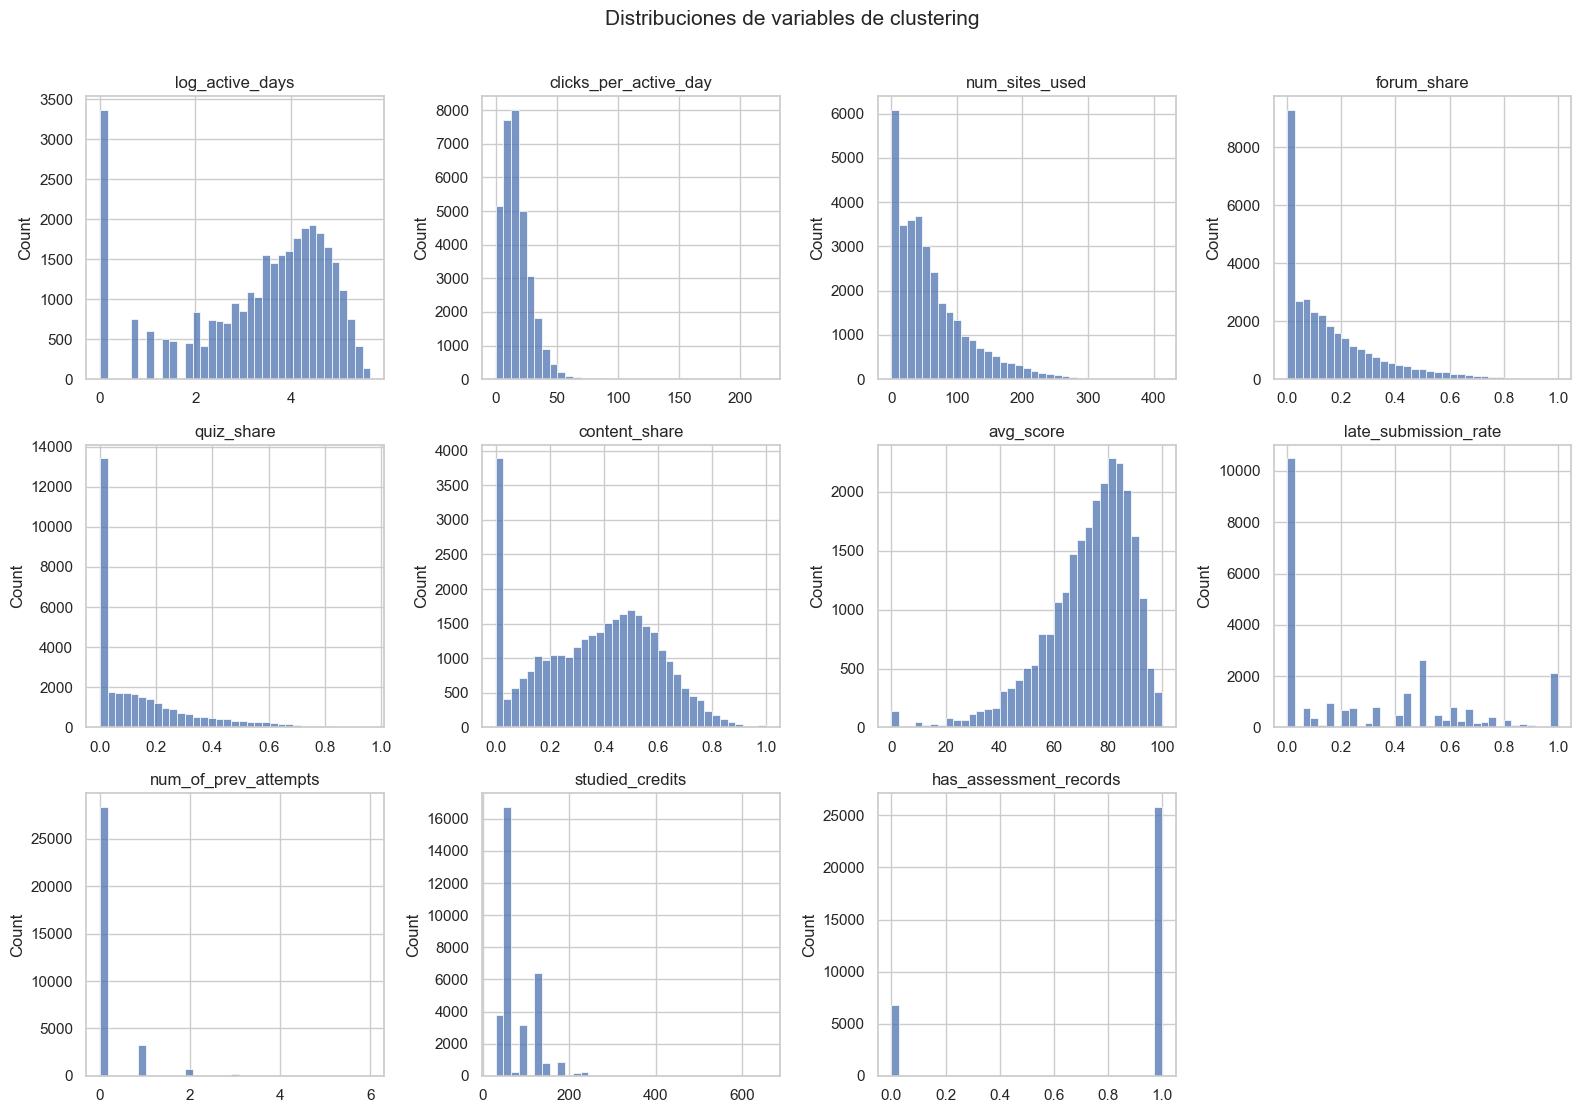

In [26]:
X_cluster_raw = maestro_clustering[CLUSTER_FEATURES].replace([np.inf, -np.inf], np.nan).copy()

eda_summary = X_cluster_raw.describe(percentiles=[.01, .05, .25, .50, .75, .95, .99]).T
eda_summary["missing"] = X_cluster_raw.isna().sum()
eda_summary["missing_pct"] = X_cluster_raw.isna().mean() * 100
display(eda_summary.round(3))

fig, axes = plt.subplots(3, 4, figsize=(16, 11))
for ax, column in zip(axes.flat, CLUSTER_FEATURES):
    sns.histplot(X_cluster_raw[column], bins=35, kde=False, ax=ax)
    ax.set_title(column)
    ax.set_xlabel("")
for ax in axes.flat[len(CLUSTER_FEATURES):]:
    ax.set_visible(False)
fig.suptitle("Distribuciones de variables de clustering", y=1.01, fontsize=15)
plt.tight_layout(); plt.show()

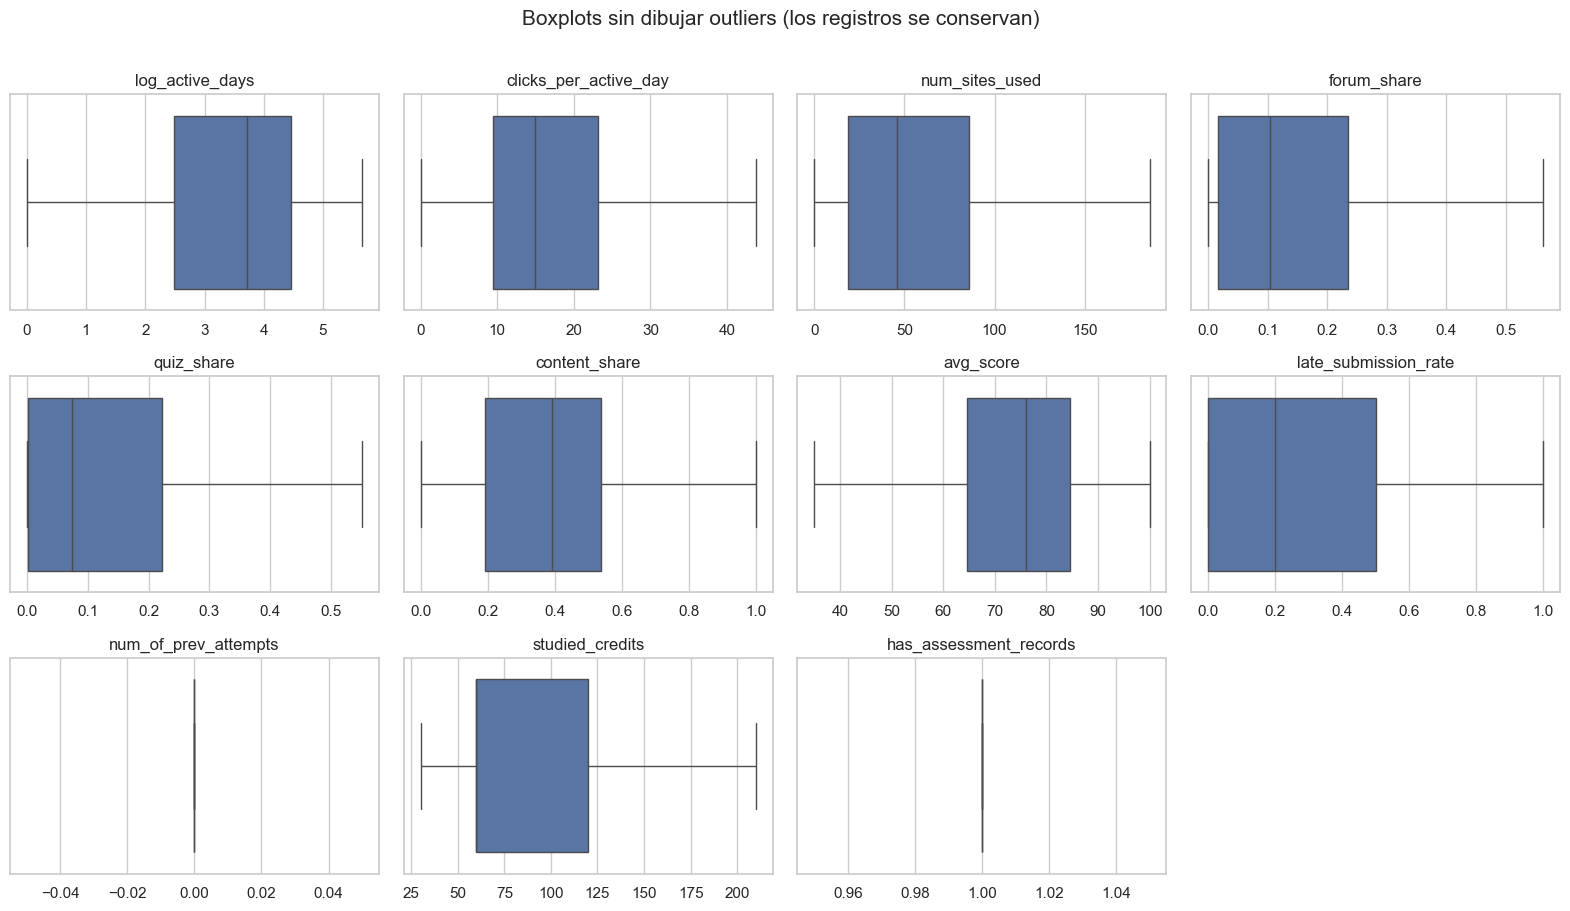

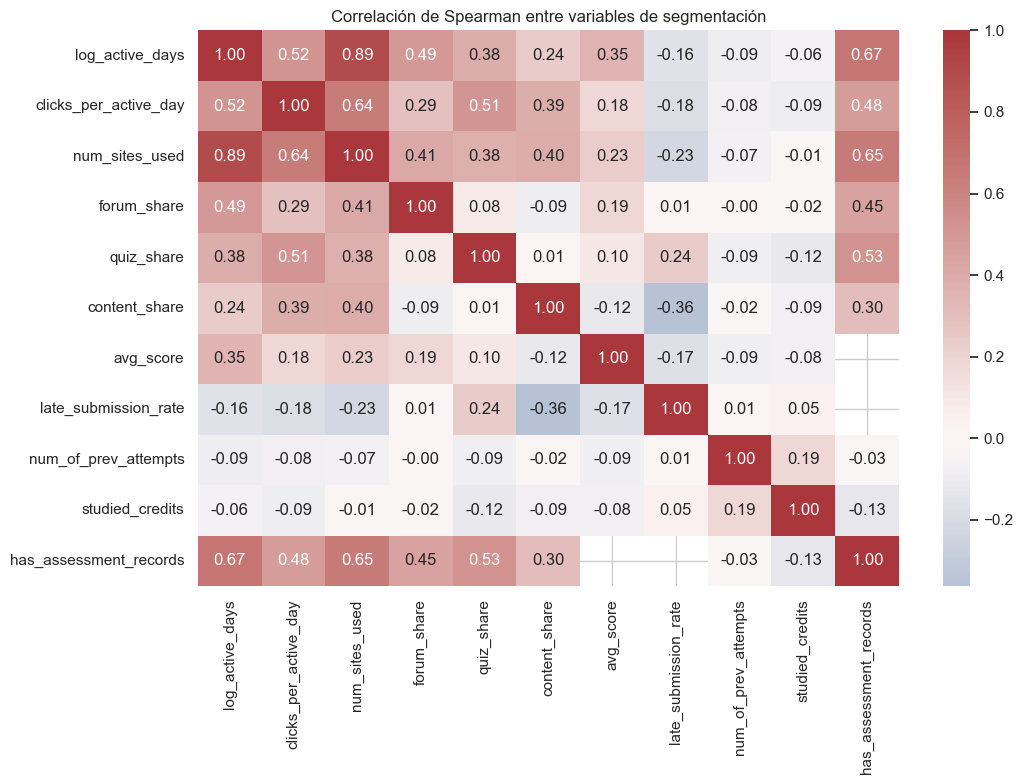

In [27]:
fig, axes = plt.subplots(3, 4, figsize=(16, 9))
for ax, column in zip(axes.flat, CLUSTER_FEATURES):
    sns.boxplot(x=X_cluster_raw[column], showfliers=False, ax=ax)
    ax.set_title(column)
    ax.set_xlabel("")
for ax in axes.flat[len(CLUSTER_FEATURES):]:
    ax.set_visible(False)
fig.suptitle("Boxplots sin dibujar outliers (los registros se conservan)", y=1.01, fontsize=15)
plt.tight_layout(); plt.show()

plt.figure(figsize=(11, 8))
sns.heatmap(X_cluster_raw.corr(method="spearman"), cmap="vlag", center=0,
            annot=True, fmt=".2f", square=False)
plt.title("Correlación de Spearman entre variables de segmentación")
plt.tight_layout(); plt.show()

### 23.4 Preprocesamiento: nulos, outliers y escalas

1. **Nulos:** imputación por mediana. No se usa cero para `avg_score` o `late_submission_rate`, porque cero tiene significado académico.
2. **Outliers:** `log_active_days` ya está transformada; las variables continuas de cola larga se winsorizan entre los percentiles 1 y 99. Se modifica una copia analítica, nunca el maestro limpio.
3. **Escalas:** `StandardScaler` centra cada variable en media cero y desviación estándar uno. Esto es imprescindible porque K-means minimiza distancias euclidianas y, sin escalado, las variables de mayor magnitud dominarían el resultado.

In [28]:
cluster_imputer = SimpleImputer(strategy="median")
X_imputed = pd.DataFrame(
    cluster_imputer.fit_transform(X_cluster_raw),
    columns=CLUSTER_FEATURES,
    index=maestro_clustering.index,
)
imputation_report = pd.DataFrame({
    "variable": CLUSTER_FEATURES,
    "nulos_imputados": X_cluster_raw.isna().sum().values,
    "mediana_aplicada": cluster_imputer.statistics_,
})
display(imputation_report)

outlier_treatment_columns = [
    "clicks_per_active_day", "num_sites_used",
    "num_of_prev_attempts", "studied_credits"
]
X_winsorized = X_imputed.copy()
winsor_rows = []
for column in outlier_treatment_columns:
    lower, upper = X_imputed[column].quantile([.01, .99])
    affected = ~X_imputed[column].between(lower, upper)
    X_winsorized[column] = X_imputed[column].clip(lower=lower, upper=upper)
    winsor_rows.append({
        "variable": column, "percentil_1": lower, "percentil_99": upper,
        "valores_ajustados": int(affected.sum()),
    })
winsor_report = pd.DataFrame(winsor_rows)
display(winsor_report)

cluster_scaler = StandardScaler()
X_scaled = cluster_scaler.fit_transform(X_winsorized)
scaled_check = pd.DataFrame(X_scaled, columns=CLUSTER_FEATURES).agg(["mean", "std"]).T
display(scaled_check.round(4))

,variable,nulos_imputados,mediana_aplicada
0,log_active_days,0,3.713572
1,clicks_per_active_day,0,15.000000
2,num_sites_used,0,46.000000
3,forum_share,0,0.104082
4,quiz_share,0,0.073786
5,content_share,0,0.392031
6,avg_score,6773,76.000000
7,late_submission_rate,6751,0.200000
8,num_of_prev_attempts,0,0.000000
9,studied_credits,0,60.000000


,variable,percentil_1,percentil_99,valores_ajustados
0,clicks_per_active_day,0.0,55.561488,326
1,num_sites_used,0.0,243.000000,319
2,num_of_prev_attempts,0.0,2.000000,198
3,studied_credits,30.0,240.000000,116


,mean,std
log_active_days,-0.0,1.0
clicks_per_active_day,0.0,1.0
num_sites_used,0.0,1.0
forum_share,-0.0,1.0
quiz_share,0.0,1.0
content_share,0.0,1.0
avg_score,-0.0,1.0
late_submission_rate,-0.0,1.0
num_of_prev_attempts,0.0,1.0
studied_credits,0.0,1.0


### 23.5 Selección matemática del número de clusters

Se evalúan `k=2,...,8` mediante:

- **Inercia:** suma de cuadrados intra-cluster; menor es mejor, aunque siempre disminuye al aumentar `k`.
- **Silhouette:** combina cohesión y separación, con rango `[-1,1]`; mayor es mejor.
- **Calinski–Harabasz:** relación entre dispersión inter e intra-cluster; mayor es mejor.
- **Davies–Bouldin:** similitud media con el cluster vecino; menor es mejor.

Silhouette se estima sobre una muestra reproducible de hasta 5.000 estudiantes para controlar su costo cuadrático. K-means siempre se ajusta con todos los registros.

In [29]:
cluster_evaluations = []
models_by_k = {}
for k in range(2, 9):
    model = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=20)
    labels = model.fit_predict(X_scaled)
    models_by_k[k] = model
    cluster_evaluations.append({
        "k": k,
        "inertia": model.inertia_,
        "silhouette": silhouette_score(
            X_scaled, labels, sample_size=min(5000, len(labels)),
            random_state=RANDOM_STATE,
        ),
        "calinski_harabasz": calinski_harabasz_score(X_scaled, labels),
        "davies_bouldin": davies_bouldin_score(X_scaled, labels),
        "smallest_cluster": int(pd.Series(labels).value_counts().min()),
    })

cluster_metrics = pd.DataFrame(cluster_evaluations)
display(cluster_metrics.round(4))
best_k = int(cluster_metrics.loc[cluster_metrics["silhouette"].idxmax(), "k"])
print(f"k recomendado por máximo Silhouette: {best_k}")

C:\Users\jllr3\AppData\Roaming\Python\Python312\site-packages\joblib\externals\loky\backend\context.py:131: UserWarning: Could not find the number of physical cores for the following reason:
found 0 physical cores < 1
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\Users\jllr3\AppData\Roaming\Python\Python312\site-packages\joblib\externals\loky\backend\context.py", line 255, in _count_physical_cores
    raise ValueError(f"found {cpu_count_physical} physical cores < 1")


,k,inertia,silhouette,calinski_harabasz,davies_bouldin,smallest_cluster
0,2,279133.9392,0.2757,9269.2741,1.3476,6748
1,3,241446.4695,0.2236,7901.3897,1.8606,6701
2,4,217898.9371,0.2211,7010.5928,1.6201,5543
3,5,197515.7578,0.2091,6641.1238,1.6369,4517
4,6,180301.2546,0.2171,6442.2363,1.5213,2832
5,7,167540.2274,0.2224,6190.9188,1.4842,2565
6,8,156084.3039,0.2190,6037.4653,1.4552,2448


k recomendado por máximo Silhouette: 2


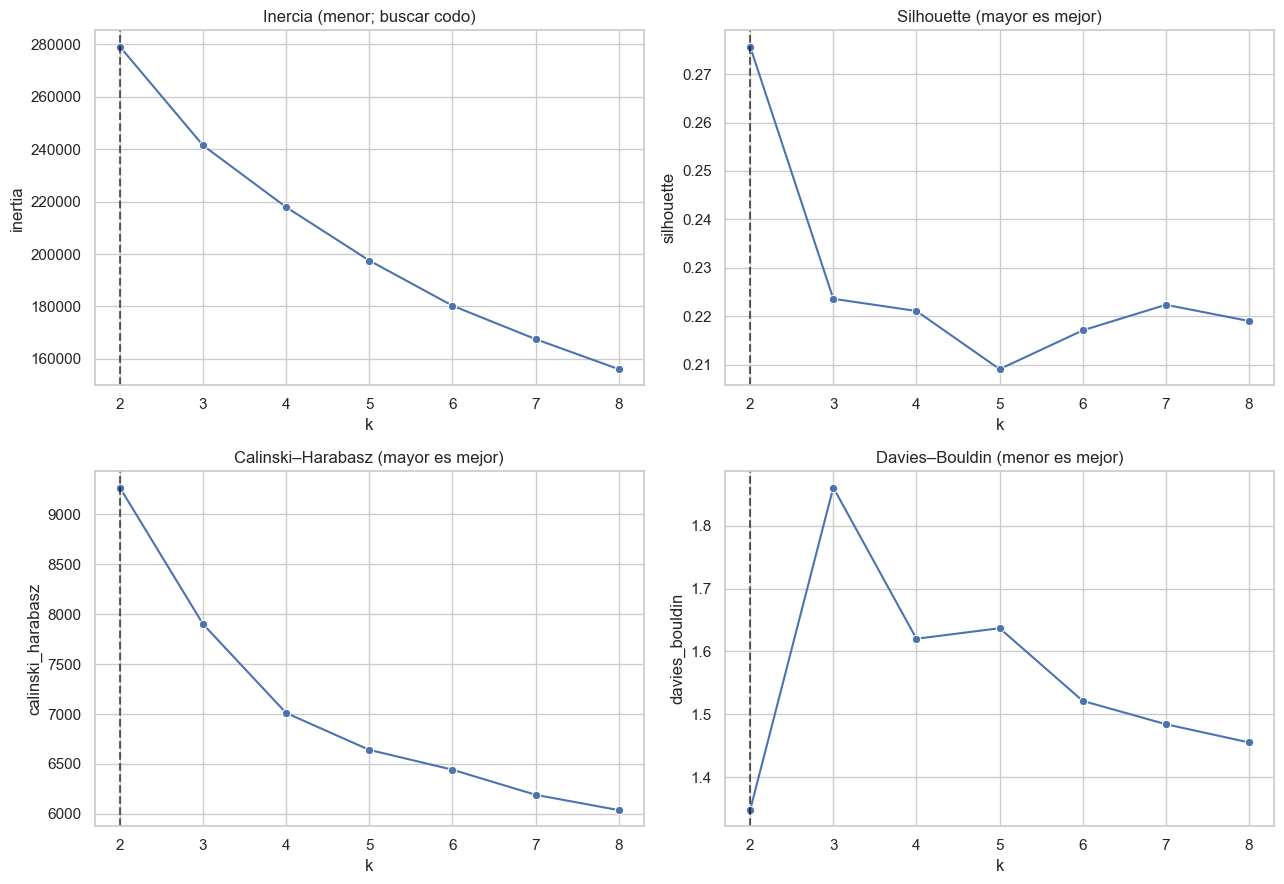

In [30]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
metric_specs = [
    ("inertia", "Inercia (menor; buscar codo)"),
    ("silhouette", "Silhouette (mayor es mejor)"),
    ("calinski_harabasz", "Calinski–Harabasz (mayor es mejor)"),
    ("davies_bouldin", "Davies–Bouldin (menor es mejor)"),
]
for ax, (metric, title) in zip(axes.flat, metric_specs):
    sns.lineplot(data=cluster_metrics, x="k", y=metric, marker="o", ax=ax)
    ax.axvline(best_k, color="black", linestyle="--", alpha=.6)
    ax.set_title(title)
plt.tight_layout(); plt.show()

### 23.6 Modelo final y perfil de clusters

El modelo final utiliza el `k` con mayor Silhouette. Los perfiles se calculan sobre valores originales e imputados solo para resumen. `target_withdrawn` se agrega después del ajuste exclusivamente como indicador descriptivo de asociación.

In [31]:
final_kmeans = models_by_k[best_k]
cluster_labels = final_kmeans.labels_
maestro_clustering["cluster"] = cluster_labels

# Para perfilar se usan valores originales; las medias ignoran NaN.
# La imputación se utiliza para ajustar K-means, no para describir desempeño observado.
profile_source = maestro_clustering[CLUSTER_FEATURES].copy()
profile_source["cluster"] = cluster_labels
profile_source["target_withdrawn"] = maestro_clustering["target_withdrawn"].to_numpy()

cluster_profile = profile_source.groupby("cluster").agg(
    n=("cluster", "size"),
    log_active_days=("log_active_days", "mean"),
    clicks_per_active_day=("clicks_per_active_day", "mean"),
    num_sites_used=("num_sites_used", "mean"),
    forum_share=("forum_share", "mean"),
    quiz_share=("quiz_share", "mean"),
    content_share=("content_share", "mean"),
    avg_score=("avg_score", "mean"),
    avg_score_available_pct=("avg_score", lambda values: 100 * values.notna().mean()),
    late_submission_rate=("late_submission_rate", "mean"),
    late_rate_available_pct=("late_submission_rate", lambda values: 100 * values.notna().mean()),
    num_of_prev_attempts=("num_of_prev_attempts", "mean"),
    studied_credits=("studied_credits", "mean"),
    has_assessment_records=("has_assessment_records", "mean"),
    withdrawal_rate=("target_withdrawn", "mean"),
)
cluster_profile.insert(1, "pct", 100 * cluster_profile["n"] / len(profile_source))
display(cluster_profile.round(3))

,n,pct,log_active_days,clicks_per_active_day,num_sites_used,forum_share,quiz_share,content_share,avg_score,avg_score_available_pct,late_submission_rate,late_rate_available_pct,num_of_prev_attempts,studied_credits,has_assessment_records,withdrawal_rate
cluster,,,,,,,,,,,,,,,,
0,25845,79.296,3.916,19.990,74.281,0.183,0.176,0.408,72.831,99.091,0.308,99.172,0.151,76.680,0.992,0.185
1,6748,20.704,0.799,5.918,6.031,0.058,0.026,0.218,65.061,3.112,0.090,3.127,0.211,91.549,0.031,0.795


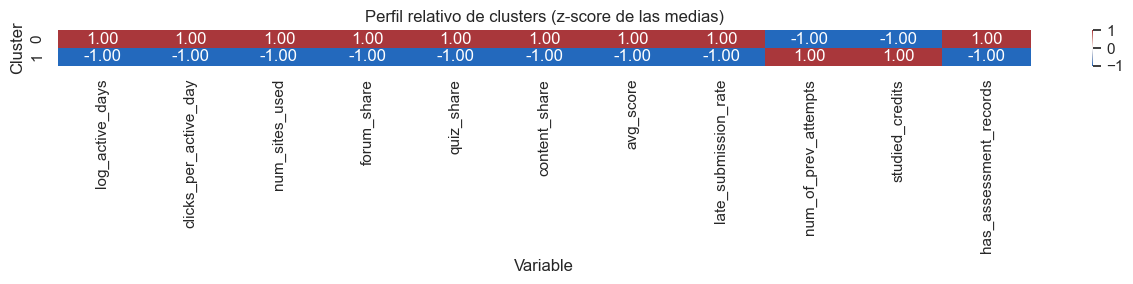

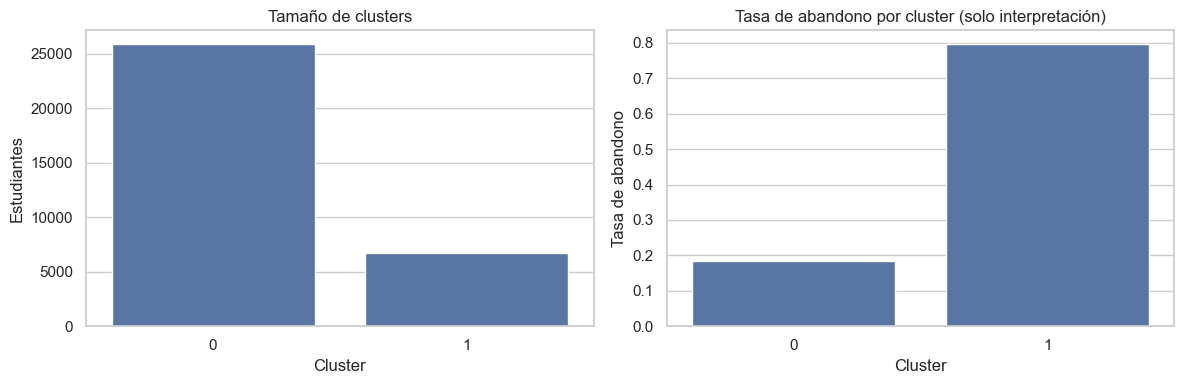

In [32]:
profile_features = CLUSTER_FEATURES
profile_z = cluster_profile[profile_features].apply(
    lambda column: (column - column.mean()) / (column.std(ddof=0) if column.std(ddof=0) else 1)
)
plt.figure(figsize=(13, max(3, .75 * best_k)))
sns.heatmap(profile_z, cmap="vlag", center=0, annot=True, fmt=".2f")
plt.title("Perfil relativo de clusters (z-score de las medias)")
plt.xlabel("Variable"); plt.ylabel("Cluster")
plt.tight_layout(); plt.show()

cluster_sizes = maestro_clustering["cluster"].value_counts().sort_index()
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.barplot(x=cluster_sizes.index, y=cluster_sizes.values, ax=axes[0])
axes[0].set_title("Tamaño de clusters"); axes[0].set_xlabel("Cluster"); axes[0].set_ylabel("Estudiantes")
sns.barplot(x=cluster_profile.index, y=cluster_profile["withdrawal_rate"], ax=axes[1])
axes[1].set_title("Tasa de abandono por cluster (solo interpretación)")
axes[1].set_xlabel("Cluster"); axes[1].set_ylabel("Tasa de abandono")
plt.tight_layout(); plt.show()

### 23.7 Visualización PCA de la solución

PCA no construye los clusters: se utiliza únicamente para proyectar las variables estandarizadas en dos dimensiones. La superposición visual no reemplaza las métricas cuantitativas.

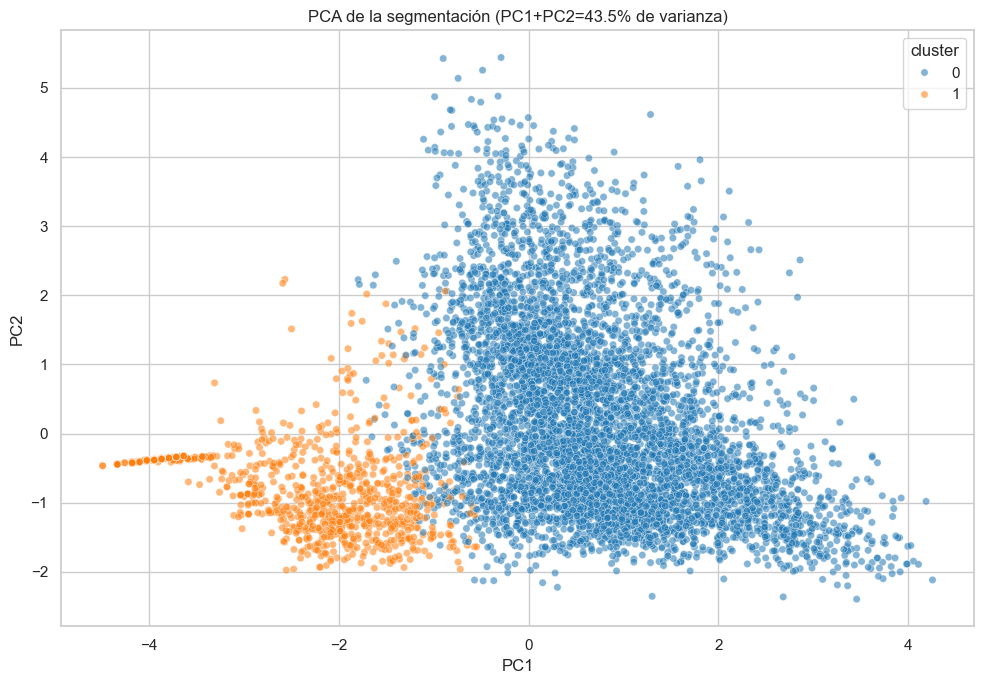

In [33]:
pca_cluster = PCA(n_components=2, random_state=RANDOM_STATE)
cluster_embedding = pca_cluster.fit_transform(X_scaled)
pca_cluster_df = pd.DataFrame({
    "PC1": cluster_embedding[:, 0],
    "PC2": cluster_embedding[:, 1],
    "cluster": cluster_labels,
})
sample_pca = pca_cluster_df.sample(min(8000, len(pca_cluster_df)), random_state=RANDOM_STATE)

plt.figure(figsize=(10, 7))
sns.scatterplot(data=sample_pca, x="PC1", y="PC2", hue="cluster",
                palette="tab10", alpha=.55, s=28)
plt.title(
    f"PCA de la segmentación (PC1+PC2={pca_cluster.explained_variance_ratio_.sum():.1%} de varianza)"
)
plt.tight_layout(); plt.show()

### 23.8 Exportación de segmentos y métricas

In [34]:
CLUSTERS_PATH = DATA_PATH / "maestro_clusters.csv"
CLUSTER_METRICS_PATH = DATA_PATH / "metricas_clustering.csv"
CLUSTER_PROFILE_PATH = DATA_PATH / "perfiles_clusters.csv"

maestro_clustering.to_csv(CLUSTERS_PATH, index=False, encoding="utf-8-sig")
cluster_metrics.to_csv(CLUSTER_METRICS_PATH, index=False, encoding="utf-8-sig")
cluster_profile.to_csv(CLUSTER_PROFILE_PATH, encoding="utf-8-sig")

display(pd.DataFrame({
    "archivo": [CLUSTERS_PATH, CLUSTER_METRICS_PATH, CLUSTER_PROFILE_PATH],
    "filas": [len(maestro_clustering), len(cluster_metrics), len(cluster_profile)],
    "tamaño_KB": [round(file.stat().st_size / 1024, 2) for file in
                   [CLUSTERS_PATH, CLUSTER_METRICS_PATH, CLUSTER_PROFILE_PATH]],
}))
print(f"Segmentación completada con k={best_k} y Silhouette="
      f"{cluster_metrics.loc[cluster_metrics.k.eq(best_k), 'silhouette'].iloc[0]:.3f}")

,archivo,filas,tamaño_KB
0,data\maestro_clusters.csv,32593,9725.73
1,data\metricas_clustering.csv,7,0.64
2,data\perfiles_clusters.csv,2,0.82


Segmentación completada con k=2 y Silhouette=0.276


### 23.9 Criterio de interpretación

Los clusters describen patrones, no tipos permanentes de estudiantes. Las diferencias de abandono son asociaciones posteriores y no demuestran causalidad. Antes de usar los segmentos para intervenciones deben comprobarse estabilidad entre cohortes, sensibilidad a preprocesamiento, tamaños suficientes y ausencia de impactos inequitativos.

## 24. Reducción dimensional: PCA y t-SNE

### Selección de variables

PCA utiliza exclusivamente variables relacionadas con intensidad y diversidad de interacción en el entorno virtual: días activos, sitios utilizados, intensidad diaria y clics en homepage, contenidos, foros, cuestionarios, recursos y URL.

Se excluyen deliberadamente:

- variables demográficas;
- calificaciones y entregas;
- `final_result` y `target_withdrawn`;
- etiquetas de cluster durante el ajuste.

Así, los componentes representan estructura de **comportamiento digital**, sin ser dirigidos por desempeño, abandono o características personales.

In [35]:
from sklearn.manifold import TSNE


PCA_FEATURES = [
    "active_days",
    "num_sites_used",
    "clicks_per_active_day",
    "clicks_homepage",
    "clicks_oucontent",
    "clicks_forumng",
    "clicks_quiz",
    "clicks_resource",
    "clicks_url",
]

missing_pca_columns = sorted(set(PCA_FEATURES) - set(maestro_clustering.columns))
if missing_pca_columns:
    raise KeyError(f"Faltan variables para PCA: {missing_pca_columns}")

pca_selection = pd.DataFrame({
    "variable": PCA_FEATURES,
    "rol": [
        "persistencia", "diversidad", "intensidad", "entrada/navegación",
        "contenido académico", "interacción social", "práctica/evaluación",
        "recursos", "enlaces externos",
    ],
    "transformación": "log1p + StandardScaler",
})
display(pca_selection)

,variable,rol,transformación
0,active_days,persistencia,log1p + StandardScaler
1,num_sites_used,diversidad,log1p + StandardScaler
2,clicks_per_active_day,intensidad,log1p + StandardScaler
3,clicks_homepage,entrada/navegación,log1p + StandardScaler
4,clicks_oucontent,contenido académico,log1p + StandardScaler
5,clicks_forumng,interacción social,log1p + StandardScaler
6,clicks_quiz,práctica/evaluación,log1p + StandardScaler
7,clicks_resource,recursos,log1p + StandardScaler
8,clicks_url,enlaces externos,log1p + StandardScaler


### 24.1 Preprocesamiento para PCA

Las variables de clics presentan asimetría positiva. Se aplica `log1p`, que admite valores cero y reduce la influencia de colas largas sin eliminar observaciones. Después se usa `StandardScaler`; PCA depende de varianzas y, sin estandarización, las variables de mayor escala dominarían los componentes.

In [36]:
X_pca_raw = maestro_clustering[PCA_FEATURES].replace([np.inf, -np.inf], np.nan).copy()
if (X_pca_raw.dropna() < 0).any().any():
    raise ValueError("PCA encontró valores negativos en variables de interacción.")

pca_imputer = SimpleImputer(strategy="median")
X_pca_imputed = pca_imputer.fit_transform(X_pca_raw)
X_pca_log = np.log1p(X_pca_imputed)
pca_scaler = StandardScaler()
X_pca_scaled = pca_scaler.fit_transform(X_pca_log)

pca_preprocessing_report = pd.DataFrame({
    "variable": PCA_FEATURES,
    "nulos_imputados": X_pca_raw.isna().sum().values,
    "mediana": pca_imputer.statistics_,
    "media_estandarizada": X_pca_scaled.mean(axis=0),
    "std_estandarizada": X_pca_scaled.std(axis=0),
})
display(pca_preprocessing_report.round(5))

,variable,nulos_imputados,mediana,media_estandarizada,std_estandarizada
0,active_days,0,40.0,-0.0,1.0
1,num_sites_used,0,46.0,0.0,1.0
2,clicks_per_active_day,0,15.0,-0.0,1.0
3,clicks_homepage,0,120.0,0.0,1.0
4,clicks_oucontent,0,73.0,0.0,1.0
5,clicks_forumng,0,68.0,-0.0,1.0
6,clicks_quiz,0,56.0,0.0,1.0
7,clicks_resource,0,19.0,-0.0,1.0
8,clicks_url,0,6.0,-0.0,1.0


### 24.2 Varianza explicada

PCA busca combinaciones lineales ortogonales que maximizan la varianza sucesiva. La proporción explicada se calcula con los datos reales; no se fijan porcentajes antes de ejecutar.

In [37]:
pca_full_digital = PCA()
X_pca_scores = pca_full_digital.fit_transform(X_pca_scaled)
pca_cumulative = np.cumsum(pca_full_digital.explained_variance_ratio_)

pca_variance = pd.DataFrame({
    "componente": [f"PC{i}" for i in range(1, len(PCA_FEATURES) + 1)],
    "varianza_explicada": pca_full_digital.explained_variance_ratio_,
    "varianza_acumulada": pca_cumulative,
})
display(pca_variance.style.format({
    "varianza_explicada": "{:.2%}",
    "varianza_acumulada": "{:.2%}",
}))

components_needed = {
    threshold: int(np.searchsorted(pca_cumulative, threshold) + 1)
    for threshold in [.80, .90, .95]
}
print(f"PC1 explica {pca_variance.loc[0, 'varianza_explicada']:.2%} de la varianza.")
print(f"PC1 + PC2 explican {pca_variance.loc[1, 'varianza_acumulada']:.2%}.")
print("Componentes requeridos para 80%, 90% y 95%:", components_needed)

,componente,varianza_explicada,varianza_acumulada
0,PC1,74.90%,74.90%
1,PC2,8.40%,83.30%
2,PC3,5.19%,88.49%
3,PC4,4.07%,92.56%
4,PC5,3.03%,95.59%
5,PC6,2.77%,98.36%
6,PC7,1.17%,99.52%
7,PC8,0.35%,99.88%
8,PC9,0.12%,100.00%


PC1 explica 74.90% de la varianza.
PC1 + PC2 explican 83.30%.
Componentes requeridos para 80%, 90% y 95%: {0.8: 2, 0.9: 4, 0.95: 5}


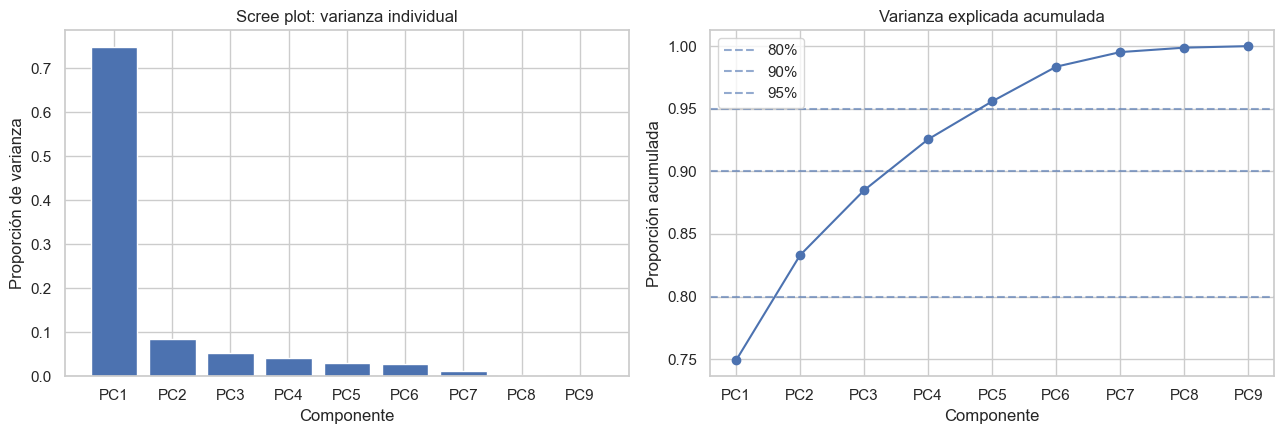

In [38]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].bar(pca_variance["componente"], pca_variance["varianza_explicada"])
axes[0].set_title("Scree plot: varianza individual")
axes[0].set_xlabel("Componente"); axes[0].set_ylabel("Proporción de varianza")

axes[1].plot(pca_variance["componente"], pca_variance["varianza_acumulada"], marker="o")
for threshold in [.80, .90, .95]:
    axes[1].axhline(threshold, linestyle="--", alpha=.6, label=f"{threshold:.0%}")
axes[1].set_title("Varianza explicada acumulada")
axes[1].set_xlabel("Componente"); axes[1].set_ylabel("Proporción acumulada")
axes[1].legend()
plt.tight_layout(); plt.show()

### 24.3 Loadings e interpretación

Los *loadings* indican cuánto contribuye cada variable a los componentes. La interpretación se fundamenta en los coeficientes observados, no en nombres asignados previamente.

,PC1,PC2,PC3
active_days,0.3723,-0.0825,0.0332
num_sites_used,0.3737,-0.0501,-0.2092
clicks_per_active_day,0.3297,0.2755,-0.2954
clicks_homepage,0.3774,-0.0577,-0.0232
clicks_oucontent,0.3159,0.1463,-0.5139
clicks_forumng,0.3335,-0.2401,0.3001
clicks_quiz,0.2411,0.7872,0.5280
clicks_resource,0.3344,-0.1284,-0.1038
clicks_url,0.2995,-0.4430,0.4728


PC1: mayores contribuciones ['clicks_homepage', 'num_sites_used', 'active_days', 'clicks_resource']; signos {'clicks_homepage': 'positivo', 'num_sites_used': 'positivo', 'active_days': 'positivo', 'clicks_resource': 'positivo'}
PC2: mayores contribuciones ['clicks_quiz', 'clicks_url', 'clicks_per_active_day', 'clicks_forumng']; signos {'clicks_quiz': 'positivo', 'clicks_url': 'negativo', 'clicks_per_active_day': 'positivo', 'clicks_forumng': 'negativo'}
PC3: mayores contribuciones ['clicks_quiz', 'clicks_oucontent', 'clicks_url', 'clicks_forumng']; signos {'clicks_quiz': 'positivo', 'clicks_oucontent': 'negativo', 'clicks_url': 'positivo', 'clicks_forumng': 'positivo'}


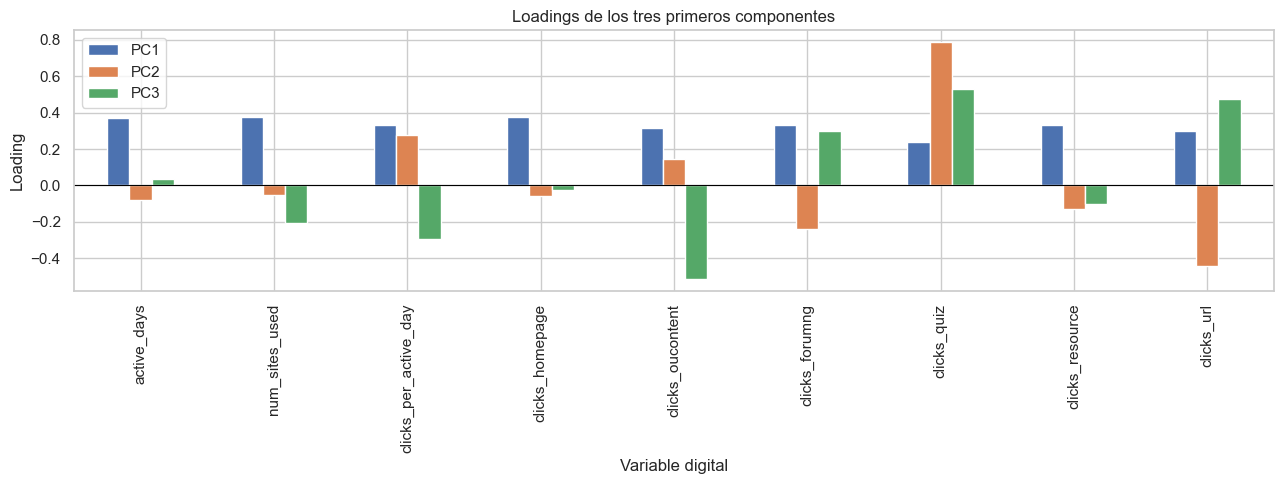

In [39]:
pca_loadings = pd.DataFrame(
    pca_full_digital.components_.T,
    index=PCA_FEATURES,
    columns=[f"PC{i}" for i in range(1, len(PCA_FEATURES) + 1)],
)
display(pca_loadings[["PC1", "PC2", "PC3"]].round(4))

for component in ["PC1", "PC2", "PC3"]:
    top = pca_loadings[component].abs().sort_values(ascending=False).head(4).index.tolist()
    signs = {feature: "positivo" if pca_loadings.loc[feature, component] >= 0 else "negativo"
             for feature in top}
    print(f"{component}: mayores contribuciones {top}; signos {signs}")

pca_loadings[["PC1", "PC2", "PC3"]].plot(kind="bar", figsize=(13, 5))
plt.title("Loadings de los tres primeros componentes")
plt.xlabel("Variable digital"); plt.ylabel("Loading")
plt.axhline(0, color="black", linewidth=.8)
plt.tight_layout(); plt.show()

### 24.4 Proyección PC1–PC2 coloreada por cluster

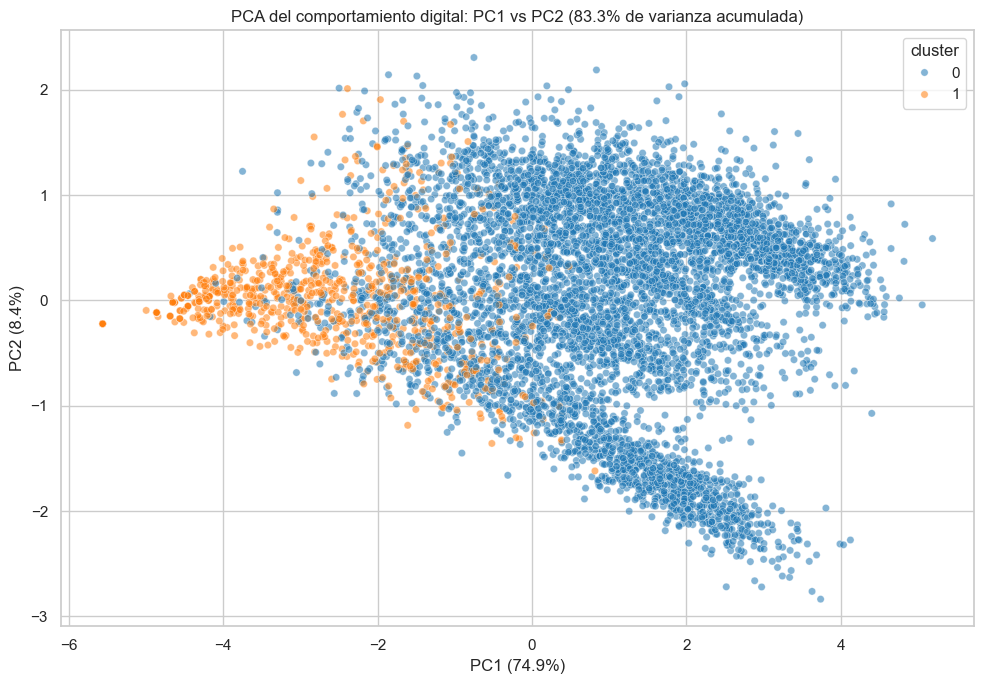

In [40]:
pca_projection = pd.DataFrame({
    "PC1": X_pca_scores[:, 0],
    "PC2": X_pca_scores[:, 1],
    "cluster": maestro_clustering["cluster"].to_numpy(),
})
pca_visual_sample = pca_projection.sample(
    min(8000, len(pca_projection)), random_state=RANDOM_STATE
)

plt.figure(figsize=(10, 7))
sns.scatterplot(data=pca_visual_sample, x="PC1", y="PC2", hue="cluster",
                palette="tab10", alpha=.55, s=28)
plt.title(
    "PCA del comportamiento digital: PC1 vs PC2 "
    f"({pca_cumulative[1]:.1%} de varianza acumulada)"
)
plt.xlabel(f"PC1 ({pca_variance.loc[0, 'varianza_explicada']:.1%})")
plt.ylabel(f"PC2 ({pca_variance.loc[1, 'varianza_explicada']:.1%})")
plt.tight_layout(); plt.show()

### 24.5 t-SNE para estructura local

t-SNE construye una representación bidimensional que intenta preservar vecindades locales. Se aplica a una muestra reproducible y proporcional por cluster para controlar costo computacional.

> **Advertencia:** t-SNE es una herramienta exploratoria. Las distancias globales, tamaños de áreas vacías y separación aparente entre grupos no constituyen una medida matemática de calidad. La evaluación cuantitativa del clustering corresponde a Silhouette y las demás métricas calculadas anteriormente.

In [41]:
TSNE_SAMPLE_SIZE = min(5000, len(maestro_clustering))
rng_tsne = np.random.default_rng(RANDOM_STATE)
sampled_indices = []
for cluster_value, group in maestro_clustering.groupby("cluster"):
    proportional_n = max(2, round(TSNE_SAMPLE_SIZE * len(group) / len(maestro_clustering)))
    proportional_n = min(proportional_n, len(group))
    sampled_indices.extend(
        rng_tsne.choice(group.index.to_numpy(), size=proportional_n, replace=False).tolist()
    )
sampled_indices = pd.Index(sampled_indices[:TSNE_SAMPLE_SIZE])
sample_positions = maestro_clustering.index.get_indexer(sampled_indices)
if (sample_positions < 0).any():
    raise RuntimeError("No fue posible mapear la muestra t-SNE.")

X_tsne_input = X_pca_scaled[sample_positions]
tsne_model = TSNE(
    n_components=2,
    random_state=RANDOM_STATE,
    init="pca",
    learning_rate="auto",
    perplexity=30,
    max_iter=1000,
)
X_tsne_embedding = tsne_model.fit_transform(X_tsne_input)

tsne_results = pd.DataFrame({
    "case_id": [f"CASE-{number:05d}" for number in range(len(sampled_indices))],
    "tSNE1": X_tsne_embedding[:, 0],
    "tSNE2": X_tsne_embedding[:, 1],
    "cluster": maestro_clustering.loc[sampled_indices, "cluster"].to_numpy(),
})
print("Muestra t-SNE:", len(tsne_results))
display(tsne_results.groupby("cluster").size().to_frame("casos"))

Muestra t-SNE: 5000


,casos
cluster,
0,3965
1,1035


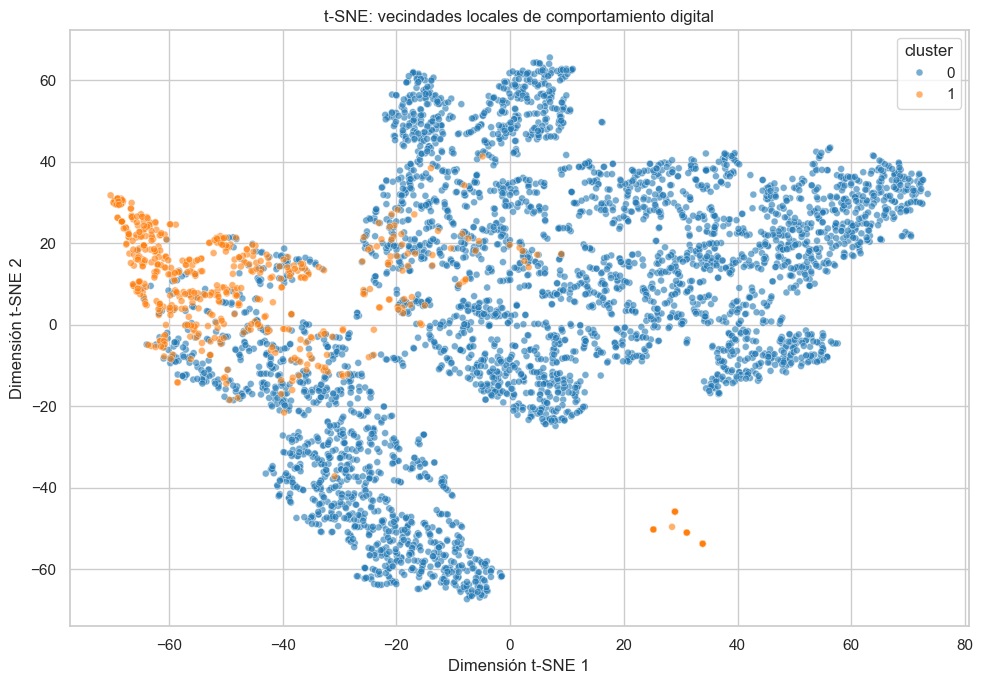

In [42]:
plt.figure(figsize=(10, 7))
sns.scatterplot(data=tsne_results, x="tSNE1", y="tSNE2", hue="cluster",
                palette="tab10", alpha=.6, s=25)
plt.title("t-SNE: vecindades locales de comportamiento digital")
plt.xlabel("Dimensión t-SNE 1"); plt.ylabel("Dimensión t-SNE 2")
plt.tight_layout(); plt.show()

### 24.6 Exportación de resultados de reducción dimensional

In [43]:
PCA_VARIANCE_PATH = DATA_PATH / "pca_varianza.csv"
PCA_LOADINGS_PATH = DATA_PATH / "pca_loadings.csv"
TSNE_PATH = DATA_PATH / "tsne_visualizacion.csv"

pca_variance.to_csv(PCA_VARIANCE_PATH, index=False, encoding="utf-8-sig")
pca_loadings.to_csv(PCA_LOADINGS_PATH, encoding="utf-8-sig")
tsne_results.to_csv(TSNE_PATH, index=False, encoding="utf-8-sig")

display(pd.DataFrame({
    "archivo": [PCA_VARIANCE_PATH, PCA_LOADINGS_PATH, TSNE_PATH],
    "filas": [len(pca_variance), len(pca_loadings), len(tsne_results)],
    "tamaño_KB": [round(file.stat().st_size / 1024, 2)
                   for file in [PCA_VARIANCE_PATH, PCA_LOADINGS_PATH, TSNE_PATH]],
}))

,archivo,filas,tamaño_KB
0,data\pca_varianza.csv,9,0.44
1,data\pca_loadings.csv,9,1.77
2,data\tsne_visualizacion.csv,5000,167.70


### 24.7 Conclusión metodológica

PCA demuestra hasta qué punto las variables digitales pueden condensarse en componentes ortogonales. Los porcentajes definitivos son los producidos por la ejecución anterior. La proyección PCA y t-SNE permiten explorar cómo los perfiles de clustering se distribuyen en espacios de menor dimensión, sin utilizar abandono, calificaciones ni demografía para construir dicha representación.

## 25. Modelado predictivo y optimización

Se compara un Árbol de Decisión regularizado con XGBoost. La evaluación final respeta el orden temporal de las presentaciones:

- **Entrenamiento:** cohortes anteriores;
- **Test final:** cohorte más reciente (`2014J` en los datos actuales).

`final_result`, `target_withdrawn`, identificadores, clusters y componentes de visualización quedan fuera de los predictores. Las variables sensibles (`gender`, `age_band`, `disability`, `imd_band`, `region`) se conservan solo para auditoría, no para predecir.

### 25.1 Advertencia de fuga temporal

Este ejercicio utiliza agregaciones disponibles durante todo el semestre para demostrar el pipeline completo. Por ello, cantidad de evaluaciones, calificaciones e interacciones tardías pueden contener información que no existiría en el momento de una alerta temprana.

En producción se debe reconstruir cada predictor usando únicamente eventos anteriores al instante de inferencia —por ejemplo, los primeros 30, 45 o 60 días—. El test temporal evita mezclar cohortes, pero no corrige por sí solo esta posible fuga dentro del semestre.

In [44]:
from sklearn.compose import ColumnTransformer
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, confusion_matrix,
    ConfusionMatrixDisplay, roc_curve, precision_recall_curve,
)
from sklearn.model_selection import RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
import xgboost

print("XGBoost:", xgboost.__version__)

MODEL_NUMERIC_FEATURES = [
    "log_total_clicks", "log_active_days", "clicks_per_active_day", "num_sites_used",
    "forum_share", "quiz_share", "content_share", "avg_score",
    "late_submission_rate", "num_of_prev_attempts", "studied_credits",
    "has_vle_records", "has_assessment_records", "num_submitted_assessments",
    "late_submissions",
]
MODEL_CATEGORICAL_FEATURES = ["code_module"]
MODEL_FEATURES = MODEL_NUMERIC_FEATURES + MODEL_CATEGORICAL_FEATURES
SENSITIVE_AUDIT_ONLY = ["gender", "age_band", "disability", "imd_band", "region"]

missing_model_features = sorted(set(MODEL_FEATURES) - set(maestro_clustering.columns))
if missing_model_features:
    raise KeyError(f"Faltan predictores: {missing_model_features}")

feature_governance = pd.DataFrame({
    "grupo": ["Predictoras numéricas", "Predictoras categóricas", "Solo auditoría",
              "Excluidas por fuga/identidad"],
    "variables": [MODEL_NUMERIC_FEATURES, MODEL_CATEGORICAL_FEATURES,
                  SENSITIVE_AUDIT_ONLY,
                  ["final_result", "target_withdrawn", "id_student",
                   "code_presentation", "cluster", "PC1", "PC2"]],
})
display(feature_governance)

XGBoost: 3.1.1


,grupo,variables
0,Predictoras numéricas,"[log_total_clicks, log_active_days, clicks_per..."
1,Predictoras categóricas,[code_module]
2,Solo auditoría,"[gender, age_band, disability, imd_band, region]"
3,Excluidas por fuga/identidad,"[final_result, target_withdrawn, id_student, c..."


### 25.2 División temporal y preprocesamiento sin fuga

In [45]:
def presentation_order(value):
    match = re.fullmatch(r"(\d{4})([BJ])", str(value))
    if not match:
        raise ValueError(f"Presentación inválida: {value}")
    return int(match.group(1)), {"B": 0, "J": 1}[match.group(2)]


ordered_cohorts = sorted(
    maestro_clustering["code_presentation"].dropna().unique(),
    key=presentation_order,
)
if len(ordered_cohorts) < 2:
    raise ValueError("Se requieren al menos dos cohortes para validación temporal.")

test_cohort = ordered_cohorts[-1]
model_train = maestro_clustering.loc[
    maestro_clustering["code_presentation"].ne(test_cohort)
].copy()
model_test = maestro_clustering.loc[
    maestro_clustering["code_presentation"].eq(test_cohort)
].copy()

X_train_model = model_train[MODEL_FEATURES]
y_train_model = model_train["target_withdrawn"].astype(int)
X_test_model = model_test[MODEL_FEATURES]
y_test_model = model_test["target_withdrawn"].astype(int)

partition_summary = pd.DataFrame({
    "partición": ["train", "test"],
    "cohortes": [ordered_cohorts[:-1], [test_cohort]],
    "filas": [len(model_train), len(model_test)],
    "tasa_abandono": [y_train_model.mean(), y_test_model.mean()],
})
display(partition_summary)

numeric_model_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])
categorical_model_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore")),
])
model_preprocessor = ColumnTransformer([
    ("numeric", numeric_model_pipeline, MODEL_NUMERIC_FEATURES),
    ("categorical", categorical_model_pipeline, MODEL_CATEGORICAL_FEATURES),
])

,partición,cohortes,filas,tasa_abandono
0,train,"[2013B, 2013J, 2014B]",21333,0.296723
1,test,[2014J],11260,0.339787


### 25.3 Modelo base: Árbol de Decisión

El árbol se restringe mediante profundidad máxima, mínimo de observaciones por división/hoja y pesos balanceados. Se evita usar un árbol irrestricto como referencia porque memorizaría patrones particulares del entrenamiento.

In [46]:
decision_tree_pipeline = Pipeline([
    ("preprocess", model_preprocessor),
    ("model", DecisionTreeClassifier(
        max_depth=6,
        min_samples_split=30,
        min_samples_leaf=15,
        class_weight="balanced",
        random_state=RANDOM_STATE,
    )),
])
decision_tree_pipeline.fit(X_train_model, y_train_model)
tree_train_probability = decision_tree_pipeline.predict_proba(X_train_model)[:, 1]
tree_test_probability = decision_tree_pipeline.predict_proba(X_test_model)[:, 1]
print("Árbol entrenado sin utilizar la cohorte de test durante el ajuste.")

Árbol entrenado sin utilizar la cohorte de test durante el ajuste.


### 25.4 XGBoost: validación temporal y selección de hiperparámetros

XGBoost construye árboles secuenciales para corregir errores anteriores. La búsqueda controla complejidad mediante:

- `max_depth`, `min_child_weight` y `gamma`;
- regularización L1 (`reg_alpha`) y L2 (`reg_lambda`);
- `subsample` y `colsample_bytree`;
- tasa de aprendizaje y número de árboles.

La selección se realiza exclusivamente sobre entrenamiento mediante folds expansivos por cohorte.

In [47]:
def expanding_temporal_splits(frame, target):
    cohorts = sorted(frame["code_presentation"].unique(), key=presentation_order)
    splits = []
    for position in range(1, len(cohorts)):
        train_positions = np.flatnonzero(frame["code_presentation"].isin(cohorts[:position]).to_numpy())
        validation_positions = np.flatnonzero(frame["code_presentation"].eq(cohorts[position]).to_numpy())
        if target.iloc[train_positions].nunique() == 2 and target.iloc[validation_positions].nunique() == 2:
            splits.append((train_positions, validation_positions))
    if len(splits) < 2:
        raise ValueError("No existen suficientes folds temporales válidos.")
    return splits


temporal_cv = expanding_temporal_splits(model_train, y_train_model)
negative_count, positive_count = np.bincount(y_train_model, minlength=2)
scale_pos_weight = negative_count / max(positive_count, 1)

xgb_search_pipeline = Pipeline([
    ("preprocess", model_preprocessor),
    ("model", XGBClassifier(
        objective="binary:logistic",
        eval_metric="auc",
        random_state=RANDOM_STATE,
        tree_method="hist",
        n_jobs=-1,
        scale_pos_weight=scale_pos_weight,
    )),
])

parameter_distributions = {
    "model__max_depth": [2, 3, 4, 5],
    "model__learning_rate": [.02, .05, .10],
    "model__n_estimators": [250, 400, 600],
    "model__min_child_weight": [1, 3, 6, 10],
    "model__subsample": [.65, .80, 1.0],
    "model__colsample_bytree": [.65, .80, 1.0],
    "model__gamma": [0, .10, .30],
    "model__reg_alpha": [0, .05, .20, 1.0],
    "model__reg_lambda": [1, 2, 5, 10],
}

xgb_search = RandomizedSearchCV(
    xgb_search_pipeline,
    parameter_distributions,
    n_iter=20,
    scoring="roc_auc",
    cv=temporal_cv,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    return_train_score=True,
    refit=True,
    verbose=1,
)
xgb_search.fit(X_train_model, y_train_model)
print("Mejor ROC-AUC temporal CV:", round(xgb_search.best_score_, 4))
print("Mejores parámetros:", xgb_search.best_params_)
display(pd.DataFrame(xgb_search.cv_results_).sort_values("rank_test_score")[[
    "mean_train_score", "mean_test_score", "std_test_score", "params"
]].head())

Fitting 2 folds for each of 20 candidates, totalling 40 fits


Mejor ROC-AUC temporal CV: 0.8997
Mejores parámetros: {'model__subsample': 0.8, 'model__reg_lambda': 1, 'model__reg_alpha': 0, 'model__n_estimators': 400, 'model__min_child_weight': 3, 'model__max_depth': 3, 'model__learning_rate': 0.02, 'model__gamma': 0, 'model__colsample_bytree': 0.65}


,mean_train_score,mean_test_score,std_test_score,params
19,0.932590,0.899664,0.012381,"{'model__subsample': 0.8, 'model__reg_lambda':..."
16,0.938449,0.899157,0.012063,"{'model__subsample': 0.65, 'model__reg_lambda'..."
14,0.932222,0.897852,0.016863,"{'model__subsample': 0.8, 'model__reg_lambda':..."
9,0.938458,0.897455,0.014326,"{'model__subsample': 1.0, 'model__reg_lambda':..."
10,0.926722,0.897100,0.016986,"{'model__subsample': 0.65, 'model__reg_lambda'..."


### 25.5 Parada temprana

La última cohorte interna de entrenamiento actúa como validación para `early stopping`. El test final nunca se usa para determinar el número de árboles.

In [48]:
inner_cohorts = sorted(model_train["code_presentation"].unique(), key=presentation_order)
early_stop_cohort = inner_cohorts[-1]
subtrain_mask = model_train["code_presentation"].ne(early_stop_cohort).to_numpy()
validation_mask = ~subtrain_mask

from sklearn.base import clone
final_model_preprocessor = clone(model_preprocessor)
X_subtrain_transformed = final_model_preprocessor.fit_transform(X_train_model.iloc[subtrain_mask])
X_validation_transformed = final_model_preprocessor.transform(X_train_model.iloc[validation_mask])
X_test_transformed = final_model_preprocessor.transform(X_test_model)

best_xgb_parameters = {
    key.replace("model__", ""): value for key, value in xgb_search.best_params_.items()
}
best_xgb_parameters["n_estimators"] = 2000
subtrain_target = y_train_model.iloc[subtrain_mask]
negative_subtrain, positive_subtrain = np.bincount(subtrain_target, minlength=2)

final_xgb = XGBClassifier(
    objective="binary:logistic",
    eval_metric="auc",
    random_state=RANDOM_STATE,
    tree_method="hist",
    n_jobs=-1,
    scale_pos_weight=negative_subtrain / max(positive_subtrain, 1),
    early_stopping_rounds=50,
    **best_xgb_parameters,
)
final_xgb.fit(
    X_subtrain_transformed,
    subtrain_target,
    eval_set=[(X_validation_transformed, y_train_model.iloc[validation_mask])],
    verbose=False,
)
print("Cohorte de early stopping:", early_stop_cohort)
print("Mejor iteración:", final_xgb.best_iteration)
print("El test final no participó en early stopping.")

Cohorte de early stopping: 2014B
Mejor iteración: 396
El test final no participó en early stopping.


### 25.6 Evaluación comparativa fuera de muestra

In [49]:
def classification_metrics(y_true, probability, threshold=.50):
    prediction = (np.asarray(probability) >= threshold).astype(int)
    return {
        "Accuracy": accuracy_score(y_true, prediction),
        "Precision": precision_score(y_true, prediction, zero_division=0),
        "Recall": recall_score(y_true, prediction, zero_division=0),
        "F1": f1_score(y_true, prediction, zero_division=0),
        "ROC-AUC": roc_auc_score(y_true, probability),
        "PR-AUC": average_precision_score(y_true, probability),
    }


X_train_transformed_final = final_model_preprocessor.transform(X_train_model)
xgb_train_probability = final_xgb.predict_proba(X_train_transformed_final)[:, 1]
xgb_validation_probability = final_xgb.predict_proba(X_validation_transformed)[:, 1]
xgb_test_probability = final_xgb.predict_proba(X_test_transformed)[:, 1]

model_comparison = pd.DataFrame({
    "Árbol de Decisión": classification_metrics(y_test_model, tree_test_probability),
    "XGBoost": classification_metrics(y_test_model, xgb_test_probability),
}).T
display(model_comparison.round(4))

generalization = pd.DataFrame({
    "partición": ["train", "validación interna", "test temporal"],
    "ROC_AUC_XGBoost": [
        roc_auc_score(y_train_model, xgb_train_probability),
        roc_auc_score(y_train_model.iloc[validation_mask], xgb_validation_probability),
        roc_auc_score(y_test_model, xgb_test_probability),
    ],
})
display(generalization.round(4))

,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC
Árbol de Decisión,0.7594,0.5926,0.9344,0.7252,0.9259,0.8542
XGBoost,0.8400,0.7064,0.9054,0.7936,0.9343,0.8760


,partición,ROC_AUC_XGBoost
0,train,0.9260
1,validación interna,0.9128
2,test temporal,0.9343


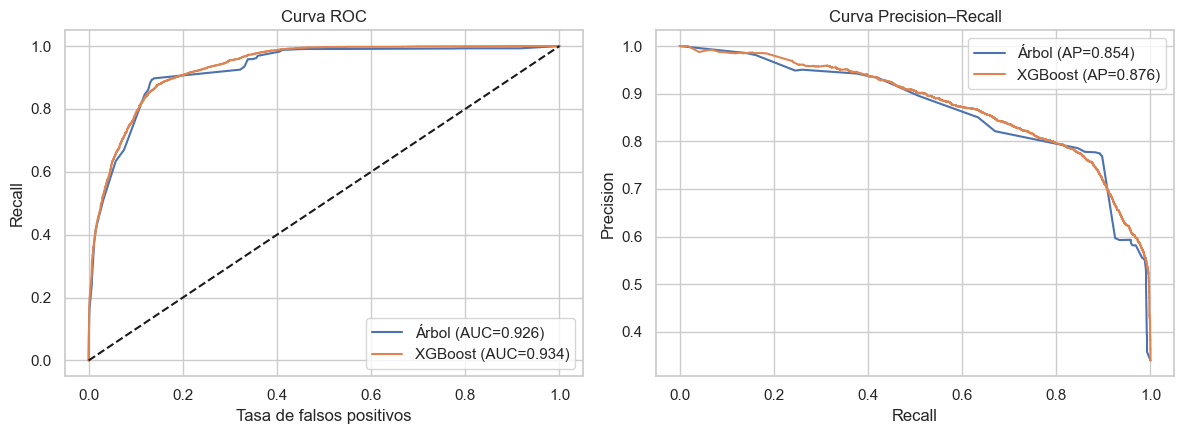

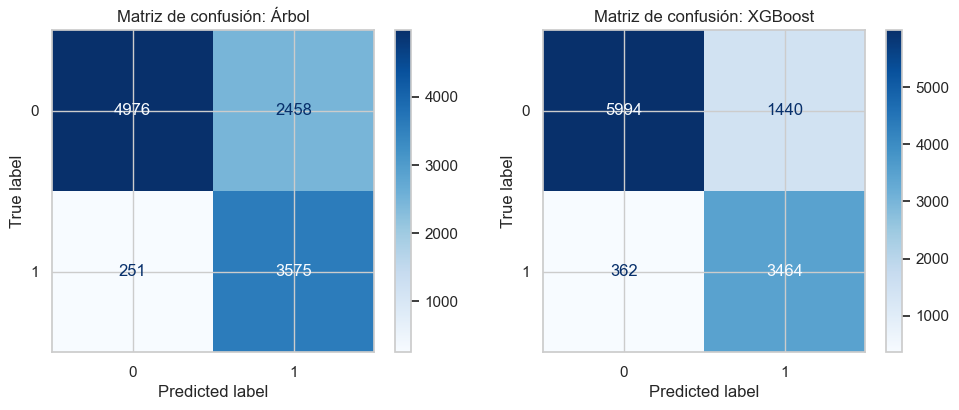

In [50]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for name, probability in {
    "Árbol": tree_test_probability,
    "XGBoost": xgb_test_probability,
}.items():
    fpr, tpr, _ = roc_curve(y_test_model, probability)
    axes[0].plot(fpr, tpr, label=f"{name} (AUC={roc_auc_score(y_test_model, probability):.3f})")
    precision, recall, _ = precision_recall_curve(y_test_model, probability)
    axes[1].plot(recall, precision,
                 label=f"{name} (AP={average_precision_score(y_test_model, probability):.3f})")
axes[0].plot([0, 1], [0, 1], "k--")
axes[0].set(title="Curva ROC", xlabel="Tasa de falsos positivos", ylabel="Recall")
axes[1].set(title="Curva Precision–Recall", xlabel="Recall", ylabel="Precision")
for axis in axes:
    axis.legend()
plt.tight_layout(); plt.show()

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for axis, name, probability in zip(
    axes, ["Árbol", "XGBoost"], [tree_test_probability, xgb_test_probability]
):
    ConfusionMatrixDisplay.from_predictions(
        y_test_model, (probability >= .50).astype(int), ax=axis, cmap="Blues"
    )
    axis.set_title(f"Matriz de confusión: {name}")
plt.tight_layout(); plt.show()

### 25.7 Selección de umbral

El umbral se selecciona con la validación interna, nunca con el test. Se maximiza F1 como ejemplo analítico; la universidad debe calibrarlo según costo de no detectar abandono, capacidad de intervención y tolerancia a alertas adicionales.

,threshold,precision,recall,f1
51,0.56,0.6864,0.8814,0.7718
54,0.59,0.6977,0.8622,0.7713
50,0.55,0.6825,0.8860,0.7710
53,0.58,0.6928,0.8691,0.7710
52,0.57,0.6892,0.8749,0.7710
55,0.60,0.7030,0.8534,0.7710
56,0.61,0.7087,0.8435,0.7702
49,0.54,0.6782,0.8886,0.7693
45,0.50,0.6658,0.9082,0.7683
46,0.51,0.6677,0.9013,0.7671


Umbral seleccionado en validación: 0.5599999999999999
Métricas test con umbral seleccionado: {'Accuracy': 0.8600355239786857, 'Precision': 0.7516778523489933, 'Recall': 0.8782017773131208, 'F1': 0.8100289296046287, 'ROC-AUC': 0.9342884573653976, 'PR-AUC': 0.8759679200788747}


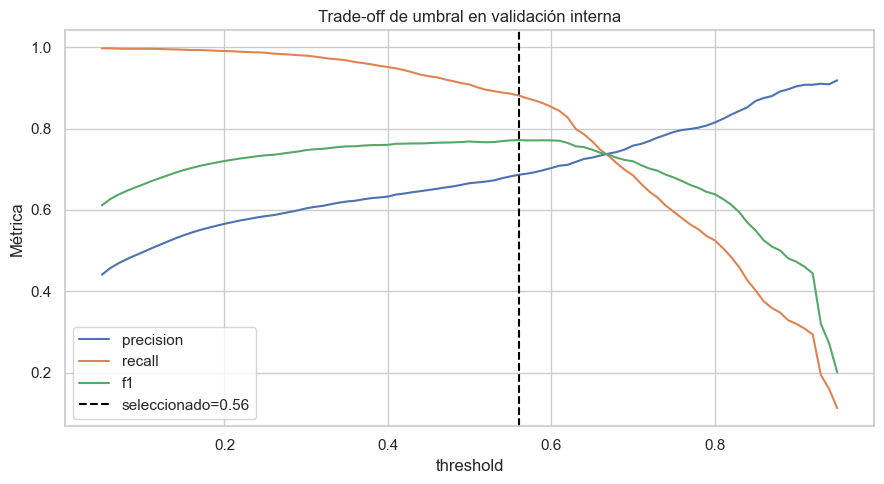

In [51]:
threshold_grid = np.linspace(.05, .95, 91)
threshold_metrics = pd.DataFrame([
    {
        "threshold": threshold,
        "precision": precision_score(
            y_train_model.iloc[validation_mask],
            (xgb_validation_probability >= threshold).astype(int), zero_division=0
        ),
        "recall": recall_score(
            y_train_model.iloc[validation_mask],
            (xgb_validation_probability >= threshold).astype(int), zero_division=0
        ),
        "f1": f1_score(
            y_train_model.iloc[validation_mask],
            (xgb_validation_probability >= threshold).astype(int), zero_division=0
        ),
    }
    for threshold in threshold_grid
])
selected_threshold = float(
    threshold_metrics.loc[threshold_metrics["f1"].idxmax(), "threshold"]
)
display(threshold_metrics.sort_values("f1", ascending=False).head(10).round(4))
print("Umbral seleccionado en validación:", selected_threshold)
print("Métricas test con umbral seleccionado:",
      classification_metrics(y_test_model, xgb_test_probability, selected_threshold))

threshold_metrics.set_index("threshold")[["precision", "recall", "f1"]].plot(figsize=(9, 5))
plt.axvline(selected_threshold, color="black", linestyle="--",
            label=f"seleccionado={selected_threshold:.2f}")
plt.title("Trade-off de umbral en validación interna")
plt.ylabel("Métrica"); plt.legend(); plt.tight_layout(); plt.show()

## 26. Interpretabilidad estadística de XGBoost

### 26.1 Importancia global por ganancia

La ganancia mide cuánto contribuyen las divisiones de una variable a reducir el error del modelo. Es una medida predictiva, no causal.

,gain
numeric__has_assessment_records,477.529938
numeric__num_submitted_assessments,298.714996
numeric__log_active_days,122.371674
categorical__code_module_EEE,107.133621
numeric__late_submissions,95.103882
categorical__code_module_GGG,60.141891
numeric__quiz_share,46.816063
categorical__code_module_FFF,41.917999
categorical__code_module_AAA,41.630592
numeric__studied_credits,39.251766


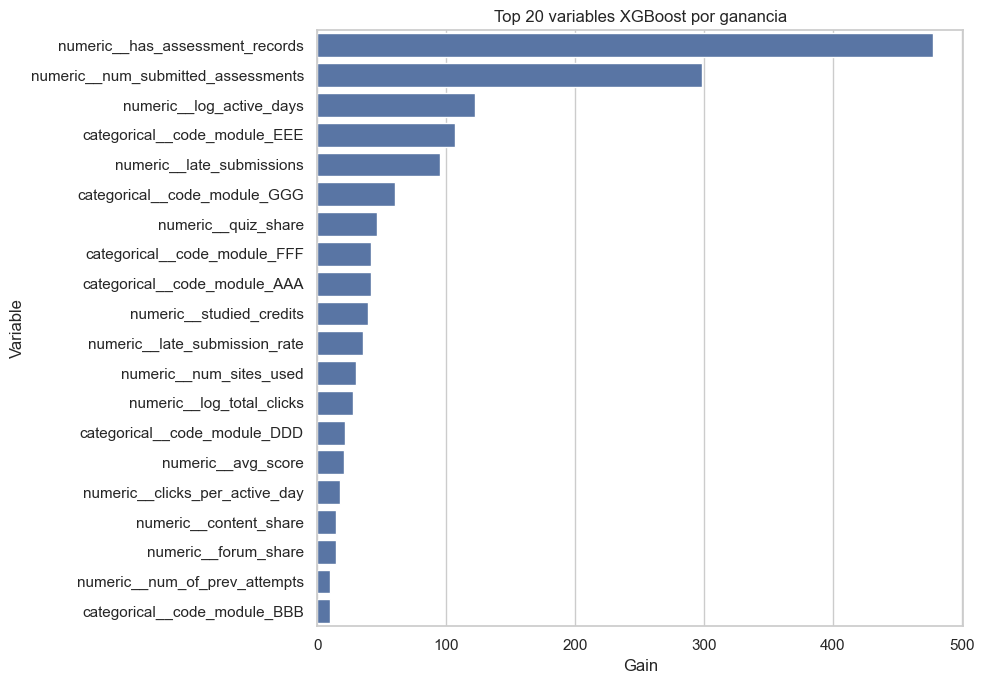

In [52]:
model_feature_names = final_model_preprocessor.get_feature_names_out()
gain_scores = final_xgb.get_booster().get_score(importance_type="gain")
global_gain_importance = pd.Series(
    {
        model_feature_names[int(key[1:])]: value
        for key, value in gain_scores.items()
        if key.startswith("f")
    },
    name="gain",
).sort_values(ascending=False)
display(global_gain_importance.head(20).to_frame())

plt.figure(figsize=(10, 7))
sns.barplot(x=global_gain_importance.head(20).values,
            y=global_gain_importance.head(20).index)
plt.title("Top 20 variables XGBoost por ganancia")
plt.xlabel("Gain"); plt.ylabel("Variable")
plt.tight_layout(); plt.show()

### 26.2 SHAP global

SHAP distribuye la diferencia entre la predicción y el valor base siguiendo principios de valores de Shapley. El gráfico global muestra magnitud y dirección de asociación con la salida del modelo. No demuestra causas reales de abandono.

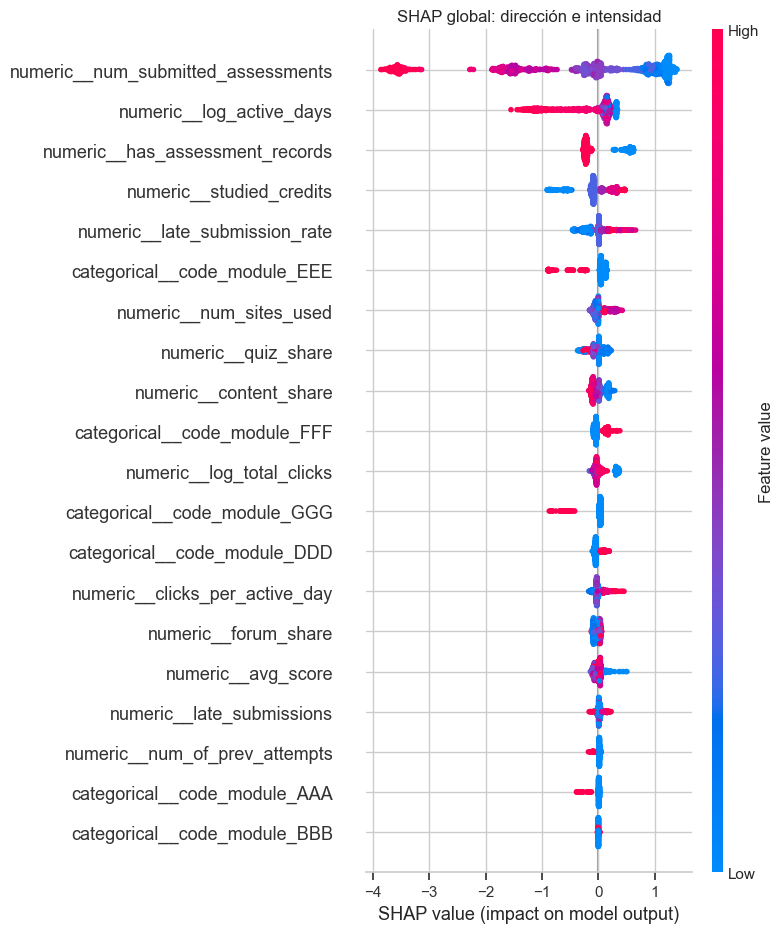

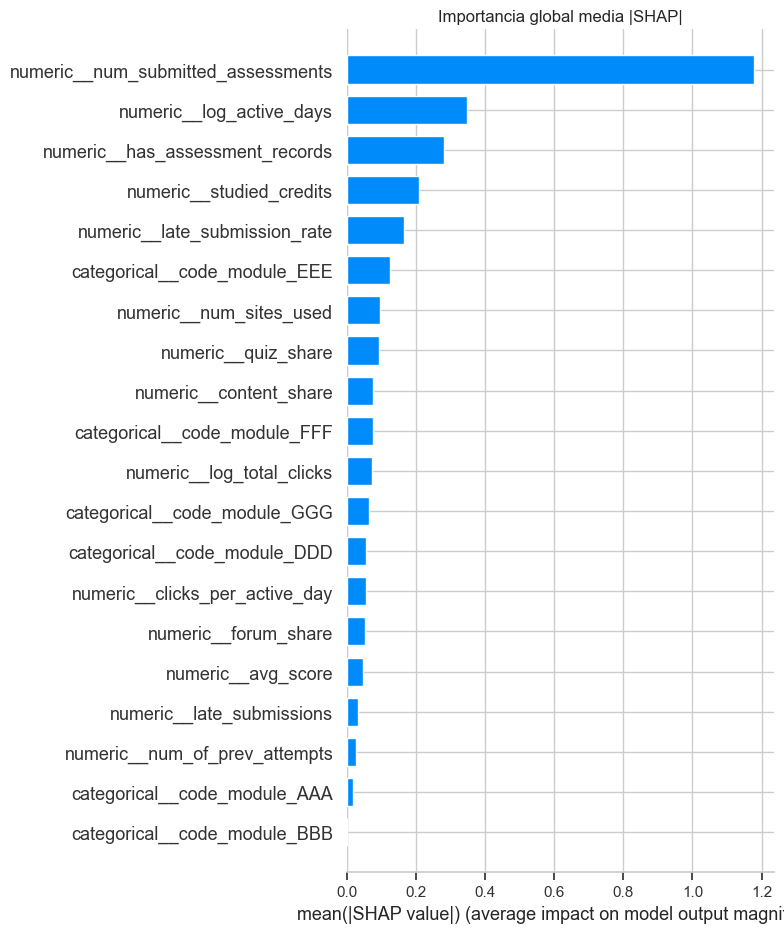

In [53]:
try:
    import shap
except ImportError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "shap"])
    import shap

shap_sample_size = min(1200, X_test_transformed.shape[0])
rng_shap = np.random.default_rng(RANDOM_STATE)
shap_positions = rng_shap.choice(
    X_test_transformed.shape[0], size=shap_sample_size, replace=False
)
X_shap_global = X_test_transformed[shap_positions]
if hasattr(X_shap_global, "toarray"):
    X_shap_global = X_shap_global.toarray()

shap_explainer = shap.TreeExplainer(final_xgb)
shap_global_values = shap_explainer(X_shap_global)

shap.summary_plot(
    shap_global_values.values, X_shap_global,
    feature_names=model_feature_names, show=False
)
plt.title("SHAP global: dirección e intensidad")
plt.tight_layout(); plt.show()

shap.summary_plot(
    shap_global_values.values, X_shap_global,
    feature_names=model_feature_names, plot_type="bar", show=False
)
plt.title("Importancia global media |SHAP|")
plt.tight_layout(); plt.show()

In [54]:
shap_global_importance = pd.DataFrame({
    "variable": model_feature_names,
    "mean_abs_SHAP": np.abs(shap_global_values.values).mean(axis=0),
}).sort_values("mean_abs_SHAP", ascending=False)
display(shap_global_importance.head(20))

,variable,mean_abs_SHAP
13,numeric__num_submitted_assessments,1.176938
1,numeric__log_active_days,0.348164
12,numeric__has_assessment_records,0.283046
10,numeric__studied_credits,0.210198
8,numeric__late_submission_rate,0.165366
18,categorical__code_module_EEE,0.126054
3,numeric__num_sites_used,0.096185
5,numeric__quiz_share,0.094132
6,numeric__content_share,0.076290
19,categorical__code_module_FFF,0.075222


### 26.3 Explicaciones locales

Se explican tres casos de test: probabilidad alta, baja y cercana al umbral. Se utilizan identificadores de caso seudonimizados; `id_student` no aparece en los reportes.

Caso seudonimizado TEST-00167
Probabilidad de abandono: 56.0%
Decisión al umbral 0.56: Alerta


,factor_que_aumenta_riesgo,valor_SHAP
0,numeric__num_sites_used,0.247635
1,numeric__studied_credits,0.207499
2,numeric__log_active_days,0.135252
3,categorical__code_module_EEE,0.131135
4,numeric__quiz_share,0.042536
5,numeric__forum_share,0.037006
6,categorical__code_module_GGG,0.032478


,factor_protector,valor_SHAP
0,numeric__has_assessment_records,-0.212246
1,numeric__late_submission_rate,-0.211295
2,categorical__code_module_FFF,-0.068477
3,numeric__avg_score,-0.067569
4,categorical__code_module_DDD,-0.042501
5,numeric__clicks_per_active_day,-0.023863
6,numeric__num_submitted_assessments,-0.018510


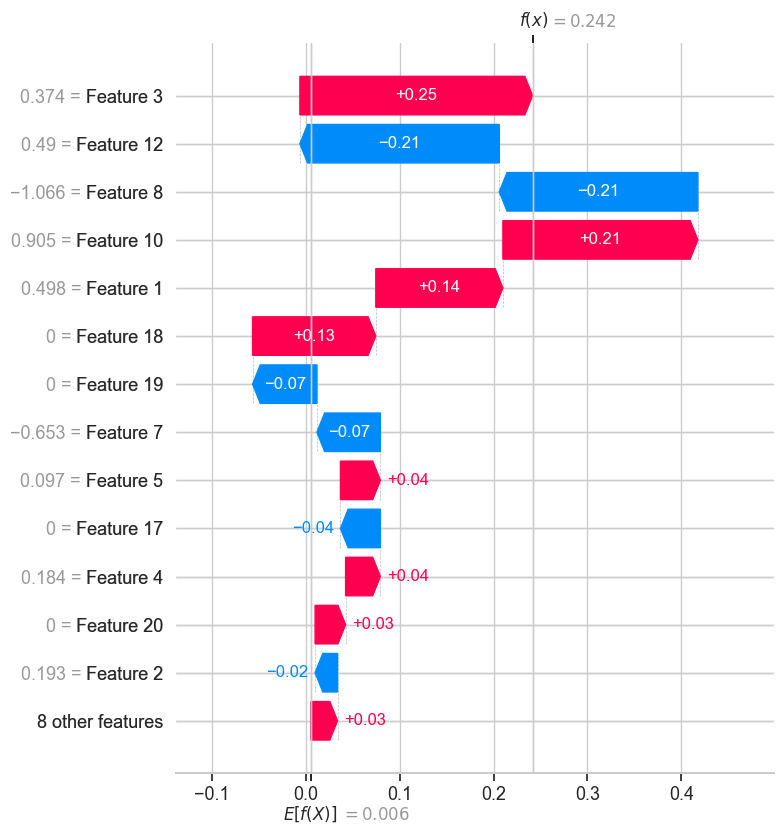

Caso seudonimizado TEST-00833
Probabilidad de abandono: 97.0%
Decisión al umbral 0.56: Alerta


,factor_que_aumenta_riesgo,valor_SHAP
0,numeric__num_submitted_assessments,1.217941
1,numeric__has_assessment_records,0.621394
2,numeric__studied_credits,0.468086
3,numeric__log_total_clicks,0.361226
4,numeric__log_active_days,0.318694
5,numeric__content_share,0.180662
6,categorical__code_module_FFF,0.127642


,factor_protector,valor_SHAP
0,categorical__code_module_DDD,-0.040181
1,numeric__forum_share,-0.017158
2,numeric__has_vle_records,0.000000
3,numeric__num_sites_used,0.002721
4,numeric__clicks_per_active_day,0.005001
5,numeric__quiz_share,0.007629
6,categorical__code_module_BBB,0.007792


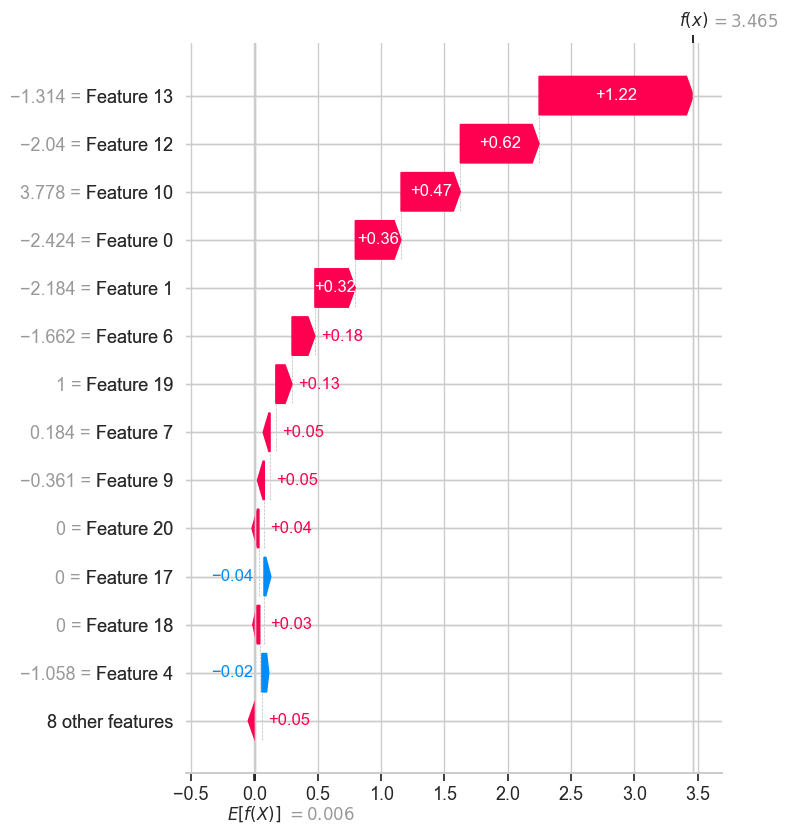

Caso seudonimizado TEST-09644
Probabilidad de abandono: 0.5%
Decisión al umbral 0.56: Sin alerta


,factor_que_aumenta_riesgo,valor_SHAP
0,categorical__code_module_FFF,0.172820
1,numeric__num_sites_used,0.115437
2,categorical__code_module_EEE,0.044835
3,categorical__code_module_GGG,0.020827
4,numeric__num_of_prev_attempts,0.008802
5,categorical__code_module_AAA,0.008361
6,categorical__code_module_BBB,0.002386


,factor_protector,valor_SHAP
0,numeric__num_submitted_assessments,-3.523843
1,numeric__log_active_days,-1.058824
2,numeric__late_submission_rate,-0.293833
3,numeric__has_assessment_records,-0.248425
4,numeric__content_share,-0.110463
5,numeric__avg_score,-0.107966
6,numeric__studied_credits,-0.102996


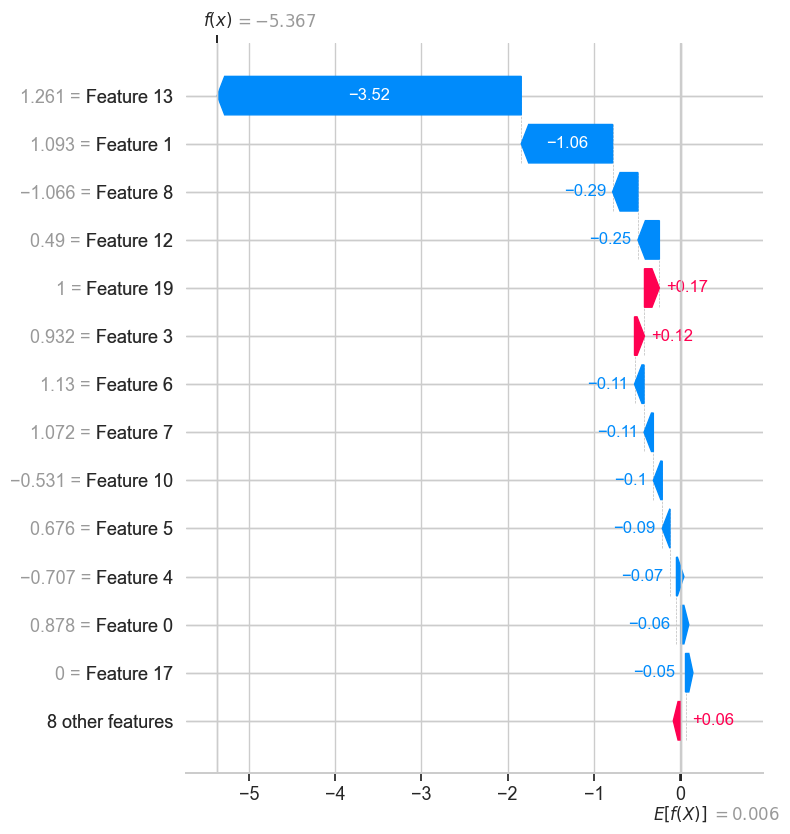

In [55]:
def explain_local_case(position, top_n=7):
    transformed_row = X_test_transformed[position:position + 1]
    if hasattr(transformed_row, "toarray"):
        transformed_row = transformed_row.toarray()
    explanation = shap_explainer(transformed_row)
    probability = float(xgb_test_probability[position])
    contributions = pd.Series(
        explanation.values[0], index=model_feature_names
    ).sort_values()
    protective = contributions.head(top_n)
    risk = contributions.tail(top_n).sort_values(ascending=False)

    print(f"Caso seudonimizado TEST-{position:05d}")
    print(f"Probabilidad de abandono: {probability:.1%}")
    print(f"Decisión al umbral {selected_threshold:.2f}:",
          "Alerta" if probability >= selected_threshold else "Sin alerta")
    display(pd.DataFrame({"factor_que_aumenta_riesgo": risk.index,
                          "valor_SHAP": risk.values}))
    display(pd.DataFrame({"factor_protector": protective.index,
                          "valor_SHAP": protective.values}))
    shap.plots.waterfall(explanation[0], max_display=14, show=False)
    plt.tight_layout(); plt.show()


local_case_positions = sorted(set([
    int(np.argmax(xgb_test_probability)),
    int(np.argmin(xgb_test_probability)),
    int(np.argmin(np.abs(xgb_test_probability - selected_threshold))),
]))
for local_position in local_case_positions:
    explain_local_case(local_position)

## 27. Recomendación ejecutiva

In [56]:
best_model = model_comparison["ROC-AUC"].idxmax()
top_global_features = shap_global_importance.head(8)["variable"].tolist()

print("MODELO Y GENERALIZACIÓN")
print(f"Mejor ROC-AUC en test temporal: {best_model} "
      f"({model_comparison.loc[best_model, 'ROC-AUC']:.3f}).")
print(f"XGBoost Recall={model_comparison.loc['XGBoost', 'Recall']:.3f}, "
      f"F1={model_comparison.loc['XGBoost', 'F1']:.3f}, "
      f"PR-AUC={model_comparison.loc['XGBoost', 'PR-AUC']:.3f}.")
print("Variables globales SHAP más influyentes:", top_global_features)
print("Umbral analítico seleccionado en validación:", selected_threshold)

MODELO Y GENERALIZACIÓN
Mejor ROC-AUC en test temporal: XGBoost (0.934).
XGBoost Recall=0.905, F1=0.794, PR-AUC=0.876.
Variables globales SHAP más influyentes: ['numeric__num_submitted_assessments', 'numeric__log_active_days', 'numeric__has_assessment_records', 'numeric__studied_credits', 'numeric__late_submission_rate', 'categorical__code_module_EEE', 'numeric__num_sites_used', 'numeric__quiz_share']
Umbral analítico seleccionado en validación: 0.5599999999999999


### Recomendación para María Fernanda y el Comité Directivo

1. **Usar el modelo para priorizar apoyo, no para sancionar.** Una alerta debe iniciar revisión humana y contacto preventivo.
2. **Intervenciones según señales reales:** baja participación → contacto/tutoría; ausencia de evaluaciones → verificación académica; retrasos → apoyo de planificación; baja calificación → refuerzo pedagógico.
3. **Calibrar el umbral institucionalmente.** El corte de este Notebook optimiza F1 en validación, pero el definitivo debe incorporar capacidad de tutores, costos y beneficios.
4. **Implementar una ventana temprana.** Reentrenar con datos truncados a 30–60 días antes de cualquier despliegue; de otro modo, la predicción puede llegar demasiado tarde.
5. **Supervisión y equidad.** Auditar recall y falsos positivos por género, edad, discapacidad e índice socioeconómico, manteniéndolos fuera del predictor salvo justificación formal.
6. **Monitorear deriva.** Revisar desempeño, calibración y explicaciones entre cohortes; suspender el uso si cambian sustancialmente.

La importancia global y SHAP describen cómo decide el modelo. No prueban que modificar una variable cause menor abandono.

### 27.1 Exportación de métricas, predicciones e interpretabilidad

In [57]:
MODEL_METRICS_PATH = DATA_PATH / "metricas_modelos.csv"
THRESHOLD_PATH = DATA_PATH / "metricas_threshold.csv"
PREDICTIONS_PATH = DATA_PATH / "predicciones_test.csv"
GAIN_PATH = DATA_PATH / "importancia_xgboost_gain.csv"
SHAP_IMPORTANCE_PATH = DATA_PATH / "importancia_shap_global.csv"

model_comparison.to_csv(MODEL_METRICS_PATH, encoding="utf-8-sig")
threshold_metrics.to_csv(THRESHOLD_PATH, index=False, encoding="utf-8-sig")
pd.DataFrame({
    "case_id": [f"TEST-{position:05d}" for position in range(len(model_test))],
    "cohort": test_cohort,
    "observed_withdrawn": y_test_model.to_numpy(),
    "probability_withdrawn": xgb_test_probability,
    "predicted_alert": (xgb_test_probability >= selected_threshold).astype(int),
}).to_csv(PREDICTIONS_PATH, index=False, encoding="utf-8-sig")
global_gain_importance.rename_axis("variable").reset_index().to_csv(
    GAIN_PATH, index=False, encoding="utf-8-sig"
)
shap_global_importance.to_csv(SHAP_IMPORTANCE_PATH, index=False, encoding="utf-8-sig")

exported_model_files = [MODEL_METRICS_PATH, THRESHOLD_PATH, PREDICTIONS_PATH,
                        GAIN_PATH, SHAP_IMPORTANCE_PATH]
display(pd.DataFrame({
    "archivo": exported_model_files,
    "tamaño_KB": [round(file.stat().st_size / 1024, 2) for file in exported_model_files],
}))

,archivo,tamaño_KB
0,data\metricas_modelos.csv,0.30
1,data\metricas_threshold.csv,6.46
2,data\predicciones_test.csv,361.13
3,data\importancia_xgboost_gain.csv,0.93
4,data\importancia_shap_global.csv,0.82


## 28. Recomendaciones específicas por cuadro y visualización

Esta sección convierte cada resultado analítico en una decisión operativa. Las acciones propuestas distinguen:

- **hallazgo medido:** resultado observado en OULAD;
- **acción recomendada:** intervención o control concreto;
- **responsable:** área que debería asumirla;
- **KPI:** indicador para comprobar si la acción funciona.

Los plazos y cortes son propuestas para piloto. No constituyen políticas definitivas de la universidad.

### 28.1 Cuadros de calidad, nulos y outliers

In [58]:
quality_positive = incidencias_calidad.loc[
    incidencias_calidad["filas_afectadas"].gt(0)
].copy()
display(quality_positive[[
    "campo", "dimension_DAMA", "severidad", "filas_afectadas", "porcentaje", "accion"
]])

quality_recommendations = pd.DataFrame([
    {
        "cuadro": "Nulos académicos",
        "hallazgo": f"{int(maestro.avg_score.isna().sum()):,} filas sin avg_score; "
                    f"{int(((maestro.has_assessment_records == 1) & maestro.avg_score.isna()).sum())} "
                    "tienen registro de evaluación pero no promedio.",
        "recomendación": "Separar ausencia de evaluación, nota aún no publicada y error de captura. "
                         "No imputar cero; usar indicador de disponibilidad y mediana dentro del pipeline.",
        "responsable": "Registro académico + Gobierno de datos",
        "KPI": "% de evaluaciones con estado y nota válidos dentro de 48 horas",
    },
    {
        "cuadro": "Consistencia imd_band",
        "hallazgo": f"Se normalizaron {imd_corrections:,} valores '10-20' a '10-20%'.",
        "recomendación": "Implementar catálogo controlado y validación al ingreso; impedir nuevas variantes de formato.",
        "responsable": "Gobierno de datos",
        "KPI": "% de valores fuera del dominio IMD = 0%",
    },
    {
        "cuadro": "Anomalías temporales",
        "hallazgo": f"{int(maestro.max_delay_days.gt(365).sum())} retrasos >365 días y "
                    f"{int((course_reference.active_days > course_reference.module_presentation_length).sum())} "
                    "casos con días activos superiores a la duración nominal.",
        "recomendación": "Contrastar eventos originales y zona temporal; conservar como válidos si corresponden a "
                         "actividad previa/posterior. Crear regla de cuarentena, no borrado automático.",
        "responsable": "Administrador LMS + Calidad de datos",
        "KPI": "% de anomalías temporales resueltas o justificadas",
    },
    {
        "cuadro": "Outliers IQR",
        "hallazgo": "Los valores extremos son frecuentes en actividad y retrasos; IQR los marca, no prueba error.",
        "recomendación": "Conservar valores originales para auditoría y usar log1p/winsorización solo en copias analíticas.",
        "responsable": "Equipo analítico",
        "KPI": "0 filas eliminadas sin evidencia de error fuente",
    },
])
display(quality_recommendations)

,campo,dimension_DAMA,severidad,filas_afectadas,porcentaje,accion
9,imd_band,Validez,Media,3516,10.7876,Estandarizar si existe equivalencia inequívoca...
56,avg_score,Completitud,Media,23,0.0706,Conservar NaN y revisar; imputar solo dentro d...
62,active_days,Oportunidad temporal,Informativa,57,0.1749,Revisar actividad previa/posterior; no elimina...
63,max_delay_days,Oportunidad temporal,Media,4,0.0123,Contrastar fecha de entrega y fecha límite ori...


,cuadro,hallazgo,recomendación,responsable,KPI
0,Nulos académicos,"6,773 filas sin avg_score; 23 tienen registro ...","Separar ausencia de evaluación, nota aún no pu...",Registro académico + Gobierno de datos,% de evaluaciones con estado y nota válidos de...
1,Consistencia imd_band,"Se normalizaron 3,516 valores '10-20' a '10-20%'.",Implementar catálogo controlado y validación a...,Gobierno de datos,% de valores fuera del dominio IMD = 0%
2,Anomalías temporales,4 retrasos >365 días y 57 casos con días activ...,Contrastar eventos originales y zona temporal;...,Administrador LMS + Calidad de datos,% de anomalías temporales resueltas o justific...
3,Outliers IQR,Los valores extremos son frecuentes en activid...,Conservar valores originales para auditoría y ...,Equipo analítico,0 filas eliminadas sin evidencia de error fuente


### 28.2 Distribuciones, correlación y preprocesamiento de clustering

In [59]:
corr_matrix = X_cluster_raw.corr(method="spearman")
upper_mask = np.triu(np.ones(corr_matrix.shape, dtype=bool), k=1)
top_correlations = (
    corr_matrix.where(upper_mask).stack().rename("rho").reset_index()
    .rename(columns={"level_0": "variable_1", "level_1": "variable_2"})
)
top_correlations["abs_rho"] = top_correlations["rho"].abs()
top_correlations = top_correlations.sort_values("abs_rho", ascending=False).head(8)
display(top_correlations.round(3))

clustering_preprocess_recommendations = pd.DataFrame([
    {
        "cuadro": "Histogramas y boxplots",
        "hallazgo": "La interacción presenta colas largas y concentración de estudiantes con actividad baja.",
        "recomendación": "Mantener log1p para días/clics y winsorización 1–99 solo durante clustering; "
                         "crear alerta operativa por caída respecto del historial individual, no por un valor absoluto único.",
        "responsable": "Analítica de aprendizaje",
        "KPI": "% de alertas basadas en cambio individual y no solo en comparación poblacional",
    },
    {
        "cuadro": "Matriz de correlación",
        "hallazgo": f"La mayor correlación absoluta observada es {top_correlations.iloc[0].abs_rho:.2f} "
                    f"entre {top_correlations.iloc[0].variable_1} y {top_correlations.iloc[0].variable_2}.",
        "recomendación": "En modelos lineales, revisar colinealidad y seleccionar una variable por constructo. "
                         "En árboles, conservarlas solo si mejoran validación temporal.",
        "responsable": "Equipo de ciencia de datos",
        "KPI": "Brecha train-validación y estabilidad de importancia entre cohortes",
    },
    {
        "cuadro": "Imputación y escalado",
        "hallazgo": "Las notas y tasas faltantes se imputaron por mediana; K-means usa variables estandarizadas.",
        "recomendación": "Guardar imputadores/scalers junto al modelo y prohibir recalcularlos con la cohorte de test o producción.",
        "responsable": "MLOps",
        "KPI": "100% de transformaciones versionadas y ajustadas solo con entrenamiento",
    },
])
display(clustering_preprocess_recommendations)

,variable_1,variable_2,rho,abs_rho
1,log_active_days,num_sites_used,0.892,0.892
9,log_active_days,has_assessment_records,0.674,0.674
26,num_sites_used,has_assessment_records,0.650,0.650
10,clicks_per_active_day,num_sites_used,0.639,0.639
39,quiz_share,has_assessment_records,0.528,0.528
0,log_active_days,clicks_per_active_day,0.520,0.520
12,clicks_per_active_day,quiz_share,0.510,0.510
2,log_active_days,forum_share,0.492,0.492


,cuadro,hallazgo,recomendación,responsable,KPI
0,Histogramas y boxplots,La interacción presenta colas largas y concent...,Mantener log1p para días/clics y winsorización...,Analítica de aprendizaje,% de alertas basadas en cambio individual y no...
1,Matriz de correlación,La mayor correlación absoluta observada es 0.8...,"En modelos lineales, revisar colinealidad y se...",Equipo de ciencia de datos,Brecha train-validación y estabilidad de impor...
2,Imputación y escalado,Las notas y tasas faltantes se imputaron por m...,Guardar imputadores/scalers junto al modelo y ...,MLOps,100% de transformaciones versionadas y ajustad...


### 28.3 Métricas y perfiles de clustering

In [60]:
risk_cluster = int(cluster_profile["withdrawal_rate"].idxmax())
engaged_cluster = int(cluster_profile["withdrawal_rate"].idxmin())
risk_row = cluster_profile.loc[risk_cluster]
engaged_row = cluster_profile.loc[engaged_cluster]

cluster_recommendations = pd.DataFrame([
    {
        "cuadro": "Elbow, Silhouette, CH y DB",
        "hallazgo": f"k={best_k}, Silhouette="
                    f"{cluster_metrics.loc[cluster_metrics.k.eq(best_k), 'silhouette'].iloc[0]:.3f}; "
                    "la separación es moderada.",
        "recomendación": "Usar los clusters como macrosegmentos de priorización, no como etiquetas permanentes. "
                         "Recalcular por cohorte y exigir estabilidad antes de operar.",
        "responsable": "Analítica + Comité académico",
        "KPI": "Silhouette por cohorte y porcentaje de estudiantes que cambia de cluster",
    },
    {
        "cuadro": "Perfil del cluster de mayor riesgo",
        "hallazgo": f"Cluster {risk_cluster}: {int(risk_row.n):,} estudiantes ({risk_row.pct:.1f}%), "
                    f"abandono observado {risk_row.withdrawal_rate:.1%}, "
                    f"has_assessment_records={risk_row.has_assessment_records:.3f}.",
        "recomendación": "Activar verificación académica cuando no exista la primera evaluación esperada; "
                         "contacto humano dentro de 48 horas y diagnóstico de acceso, carga o intención de retiro.",
        "responsable": "Tutor + Registro académico",
        "KPI": "% contactado en 48 h; % que presenta la siguiente evaluación; retención a 30 días",
    },
    {
        "cuadro": "Perfil del cluster de mayor participación",
        "hallazgo": f"Cluster {engaged_cluster}: {int(engaged_row.n):,} estudiantes, "
                    f"abandono observado {engaged_row.withdrawal_rate:.1%}.",
        "recomendación": "No consumir capacidad intensiva con contacto universal; mantener seguimiento automático "
                         "y detectar caídas abruptas respecto de su propio patrón.",
        "responsable": "Plataforma de alertas",
        "KPI": "Tasa de caída de actividad detectada antes de una entrega omitida",
    },
])
display(cluster_recommendations)

,cuadro,hallazgo,recomendación,responsable,KPI
0,"Elbow, Silhouette, CH y DB","k=2, Silhouette=0.276; la separación es moderada.",Usar los clusters como macrosegmentos de prior...,Analítica + Comité académico,Silhouette por cohorte y porcentaje de estudia...
1,Perfil del cluster de mayor riesgo,"Cluster 1: 6,748 estudiantes (20.7%), abandono...",Activar verificación académica cuando no exist...,Tutor + Registro académico,% contactado en 48 h; % que presenta la siguie...
2,Perfil del cluster de mayor participación,"Cluster 0: 25,845 estudiantes, abandono observ...",No consumir capacidad intensiva con contacto u...,Plataforma de alertas,Tasa de caída de actividad detectada antes de ...


### 28.4 PCA y t-SNE

In [61]:
pca_tsne_recommendations = pd.DataFrame([
    {
        "cuadro": "Scree plot y varianza acumulada",
        "hallazgo": f"PC1={pca_variance.loc[0, 'varianza_explicada']:.1%}; "
                    f"PC1+PC2={pca_variance.loc[1, 'varianza_acumulada']:.1%}.",
        "recomendación": "Usar PC1 como índice exploratorio de intensidad digital en tableros, "
                         "pero conservar las variables originales para explicar e intervenir.",
        "responsable": "BI académico",
        "KPI": "Correlación y estabilidad mensual del índice PC1",
    },
    {
        "cuadro": "Loadings PCA",
        "hallazgo": "PC1 resume participación general; PC2 contrasta cuestionarios frente a navegación por URL.",
        "recomendación": "Distinguir baja actividad general de una preferencia de recurso. No enviar la misma intervención "
                         "a quien estudia por URL y a quien dejó de ingresar.",
        "responsable": "Diseño instruccional",
        "KPI": "Uso de recursos y finalización de actividades por módulo",
    },
    {
        "cuadro": "Dispersión PCA",
        "hallazgo": "Los clusters se proyectan en un espacio que conserva 83,3% de la varianza digital en dos ejes.",
        "recomendación": "Usar el gráfico para monitorear cambios de cohorte y casos atípicos, no para asignar riesgo individual.",
        "responsable": "Analítica",
        "KPI": "Deriva de centroides PCA entre presentaciones",
    },
    {
        "cuadro": "t-SNE",
        "hallazgo": "La figura muestra vecindades locales en una muestra de 5.000 casos.",
        "recomendación": "Utilizarla para formular hipótesis y revisar bolsillos locales; prohibir umbrales basados en distancia visual.",
        "responsable": "Ciencia de datos",
        "KPI": "0 decisiones automatizadas basadas únicamente en coordenadas t-SNE",
    },
])
display(pca_tsne_recommendations)

,cuadro,hallazgo,recomendación,responsable,KPI
0,Scree plot y varianza acumulada,PC1=74.9%; PC1+PC2=83.3%.,Usar PC1 como índice exploratorio de intensida...,BI académico,Correlación y estabilidad mensual del índice PC1
1,Loadings PCA,PC1 resume participación general; PC2 contrast...,Distinguir baja actividad general de una prefe...,Diseño instruccional,Uso de recursos y finalización de actividades ...
2,Dispersión PCA,Los clusters se proyectan en un espacio que co...,Usar el gráfico para monitorear cambios de coh...,Analítica,Deriva de centroides PCA entre presentaciones
3,t-SNE,La figura muestra vecindades locales en una mu...,Utilizarla para formular hipótesis y revisar b...,Ciencia de datos,0 decisiones automatizadas basadas únicamente ...


### 28.5 Comparación de modelos, curvas y matriz de confusión

In [62]:
xgb_threshold_prediction = (xgb_test_probability >= selected_threshold).astype(int)
tn, fp, fn, tp = confusion_matrix(
    y_test_model, xgb_threshold_prediction, labels=[0, 1]
).ravel()

risk_levels = pd.cut(
    xgb_test_probability,
    bins=[0, .35, selected_threshold, .75, 1.000001],
    labels=["Bajo", "Medio", "Alto", "Crítico"],
    right=False,
)
risk_band_table = pd.DataFrame({
    "nivel": risk_levels,
    "observed": y_test_model.to_numpy(),
    "probability": xgb_test_probability,
}).groupby("nivel", observed=False).agg(
    casos=("observed", "size"),
    abandono_observado=("observed", "mean"),
    probabilidad_media=("probability", "mean"),
).reset_index()
display(risk_band_table.style.format({
    "abandono_observado": "{:.1%}", "probabilidad_media": "{:.1%}"
}))

model_chart_recommendations = pd.DataFrame([
    {
        "cuadro": "Tabla comparativa de modelos",
        "hallazgo": f"XGBoost ROC-AUC={model_comparison.loc['XGBoost', 'ROC-AUC']:.3f}, "
                    f"F1={model_comparison.loc['XGBoost', 'F1']:.3f}; el árbol conserva mayor recall, "
                    "pero menor precisión.",
        "recomendación": "Usar XGBoost como modelo de priorización y mantener el árbol como challenger interpretable. "
                         "Reevaluar ambos en cada nueva cohorte.",
        "responsable": "Comité de modelos",
        "KPI": "ROC-AUC, PR-AUC, recall y F1 temporal por cohorte",
    },
    {
        "cuadro": "Curva ROC",
        "hallazgo": f"ROC-AUC XGBoost={model_comparison.loc['XGBoost', 'ROC-AUC']:.3f}.",
        "recomendación": "Usar ROC para seguimiento general, pero no seleccionar el umbral solo con ROC debido al desbalance.",
        "responsable": "Ciencia de datos",
        "KPI": "ROC-AUC test temporal y degradación frente a validación",
    },
    {
        "cuadro": "Curva Precision–Recall",
        "hallazgo": f"PR-AUC XGBoost={model_comparison.loc['XGBoost', 'PR-AUC']:.3f}.",
        "recomendación": "Priorizar PR-AUC, recall y precisión al dimensionar tutorías; comparar contra la prevalencia de abandono.",
        "responsable": "Analítica + Retención",
        "KPI": "Abandonos detectados por cada 100 alertas revisadas",
    },
    {
        "cuadro": "Matriz de confusión al threshold seleccionado",
        "hallazgo": f"TP={tp:,}, FN={fn:,}, FP={fp:,}, TN={tn:,}; se generan {tp + fp:,} alertas.",
        "recomendación": "Revisar primero críticos y altos. Auditar semanalmente los falsos negativos; usar los falsos positivos "
                         "para ajustar capacidad, no como justificación de sanciones.",
        "responsable": "Equipo de retención",
        "KPI": "FN/positivos reales, FP/alertas y tiempo medio de atención",
    },
])
display(model_chart_recommendations)

,nivel,casos,abandono_observado,probabilidad_media
0,Bajo,4978,2.1%,10.5%
1,Medio,1812,20.0%,45.0%
2,Alto,1912,58.5%,65.6%
3,Crítico,2558,87.6%,88.3%


,cuadro,hallazgo,recomendación,responsable,KPI
0,Tabla comparativa de modelos,"XGBoost ROC-AUC=0.934, F1=0.794; el árbol cons...",Usar XGBoost como modelo de priorización y man...,Comité de modelos,"ROC-AUC, PR-AUC, recall y F1 temporal por cohorte"
1,Curva ROC,ROC-AUC XGBoost=0.934.,"Usar ROC para seguimiento general, pero no sel...",Ciencia de datos,ROC-AUC test temporal y degradación frente a v...
2,Curva Precision–Recall,PR-AUC XGBoost=0.876.,"Priorizar PR-AUC, recall y precisión al dimens...",Analítica + Retención,Abandonos detectados por cada 100 alertas revi...
3,Matriz de confusión al threshold seleccionado,"TP=3,360, FN=466, FP=1,110, TN=6,324; se gener...",Revisar primero críticos y altos. Auditar sema...,Equipo de retención,"FN/positivos reales, FP/alertas y tiempo medio..."


### 28.6 Threshold y capacidad operativa

In [63]:
threshold_recommendations = pd.DataFrame([
    {
        "nivel": "Crítico",
        "rango_propuesto": "p >= 0.75",
        "acción": "Contacto humano en 48 h; revisar acceso, evaluación omitida, carga y bienestar.",
        "responsable": "Tutor + Bienestar",
        "SLA": "48 horas",
    },
    {
        "nivel": "Alto",
        "rango_propuesto": f"{selected_threshold:.2f} <= p < 0.75",
        "acción": "Revisión del tutor y mensaje personalizado; ofrecer tutoría académica.",
        "responsable": "Tutor académico",
        "SLA": "5 días hábiles",
    },
    {
        "nivel": "Medio",
        "rango_propuesto": f"0.35 <= p < {selected_threshold:.2f}",
        "acción": "Nudge digital, recordatorio de entregas y seguimiento de cambio de actividad.",
        "responsable": "Plataforma + Tutor",
        "SLA": "Semanal",
    },
    {
        "nivel": "Bajo",
        "rango_propuesto": "p < 0.35",
        "acción": "Monitoreo automático; no realizar contacto intensivo salvo caída abrupta.",
        "responsable": "Plataforma",
        "SLA": "Quincenal",
    },
])
display(threshold_recommendations)

print(f"El umbral {selected_threshold:.2f} produciría {tp + fp:,} alertas en la cohorte de test.")
print("Antes de operar debe compararse este volumen con la capacidad real de tutores.")

,nivel,rango_propuesto,acción,responsable,SLA
0,Crítico,p >= 0.75,"Contacto humano en 48 h; revisar acceso, evalu...",Tutor + Bienestar,48 horas
1,Alto,0.56 <= p < 0.75,Revisión del tutor y mensaje personalizado; of...,Tutor académico,5 días hábiles
2,Medio,0.35 <= p < 0.56,"Nudge digital, recordatorio de entregas y segu...",Plataforma + Tutor,Semanal
3,Bajo,p < 0.35,Monitoreo automático; no realizar contacto int...,Plataforma,Quincenal


El umbral 0.56 produciría 4,470 alertas en la cohorte de test.
Antes de operar debe compararse este volumen con la capacidad real de tutores.


### 28.7 Importancia XGBoost y SHAP global

In [64]:
shap_action_map = pd.DataFrame([
    {
        "señal": "num_submitted_assessments / has_assessment_records",
        "lectura": "Ausencia o baja cantidad de entregas es la señal dominante.",
        "acción_específica": "Tras vencer la primera evaluación, verificar en 48 h si existe problema técnico, "
                             "intención de retiro o necesidad académica.",
        "control": "No interpretar una nota no publicada como falta del estudiante.",
    },
    {
        "señal": "log_active_days / num_sites_used",
        "lectura": "Persistencia y diversidad de navegación aportan información de riesgo.",
        "acción_específica": "Pilotear alerta por 7 días consecutivos sin actividad o caída >50% frente a la línea base individual.",
        "control": "Calibrar por módulo y calendario; el umbral es una propuesta de piloto.",
    },
    {
        "señal": "late_submission_rate / late_submissions",
        "lectura": "Los retrasos repetidos se asocian con la predicción.",
        "acción_específica": "Después de dos retrasos o tasa >50%, ofrecer planificación y revisar barreras de tiempo.",
        "control": "No flexibilizar automáticamente fuera de políticas institucionales.",
    },
    {
        "señal": "studied_credits",
        "lectura": "La carga académica modifica el riesgo estimado.",
        "acción_específica": "Revisar sobrecarga y secuencia de módulos; ofrecer asesoría de planificación.",
        "control": "No recomendar reducción de créditos sin revisión humana.",
    },
    {
        "señal": "code_module",
        "lectura": "Existen diferencias predictivas entre módulos.",
        "acción_específica": "Crear tablero por módulo y revisar diseño, calendario y recursos donde se concentren alertas.",
        "control": "No atribuir causalidad al módulo ni penalizar docentes/estudiantes solo por SHAP.",
    },
    {
        "señal": "quiz_share / content_share",
        "lectura": "La composición del uso aporta información adicional a la intensidad total.",
        "acción_específica": "Ofrecer rutas hacia cuestionarios de práctica, contenidos esenciales y recursos de refuerzo.",
        "control": "Verificar accesibilidad y disponibilidad antes de interpretar bajo uso.",
    },
])
display(shap_global_importance.head(15))
display(shap_action_map)

,variable,mean_abs_SHAP
13,numeric__num_submitted_assessments,1.176938
1,numeric__log_active_days,0.348164
12,numeric__has_assessment_records,0.283046
10,numeric__studied_credits,0.210198
8,numeric__late_submission_rate,0.165366
18,categorical__code_module_EEE,0.126054
3,numeric__num_sites_used,0.096185
5,numeric__quiz_share,0.094132
6,numeric__content_share,0.076290
19,categorical__code_module_FFF,0.075222


,señal,lectura,acción_específica,control
0,num_submitted_assessments / has_assessment_rec...,Ausencia o baja cantidad de entregas es la señ...,"Tras vencer la primera evaluación, verificar e...",No interpretar una nota no publicada como falt...
1,log_active_days / num_sites_used,Persistencia y diversidad de navegación aporta...,Pilotear alerta por 7 días consecutivos sin ac...,Calibrar por módulo y calendario; el umbral es...
2,late_submission_rate / late_submissions,Los retrasos repetidos se asocian con la predi...,"Después de dos retrasos o tasa >50%, ofrecer p...",No flexibilizar automáticamente fuera de polít...
3,studied_credits,La carga académica modifica el riesgo estimado.,Revisar sobrecarga y secuencia de módulos; ofr...,No recomendar reducción de créditos sin revisi...
4,code_module,Existen diferencias predictivas entre módulos.,"Crear tablero por módulo y revisar diseño, cal...",No atribuir causalidad al módulo ni penalizar ...
5,quiz_share / content_share,La composición del uso aporta información adic...,"Ofrecer rutas hacia cuestionarios de práctica,...",Verificar accesibilidad y disponibilidad antes...


### 28.8 SHAP local: acción por estudiante

In [65]:
local_recommendation_rows = []
for position in local_case_positions:
    transformed = X_test_transformed[position:position + 1]
    if hasattr(transformed, "toarray"):
        transformed = transformed.toarray()
    local_explanation = shap_explainer(transformed)
    local_contributions = pd.Series(
        local_explanation.values[0], index=model_feature_names
    ).sort_values()
    probability = float(xgb_test_probability[position])
    if probability >= .75:
        level, action, sla = "Crítico", "Contacto humano y diagnóstico multidimensional", "48 horas"
    elif probability >= selected_threshold:
        level, action, sla = "Alto", "Revisión del tutor y oferta de apoyo", "5 días hábiles"
    elif probability >= .35:
        level, action, sla = "Medio", "Nudge y seguimiento de actividad", "Semanal"
    else:
        level, action, sla = "Bajo", "Monitoreo automático", "Quincenal"
    local_recommendation_rows.append({
        "case_id": f"TEST-{position:05d}",
        "probabilidad": probability,
        "nivel": level,
        "principales_factores_riesgo": "; ".join(local_contributions.tail(3).index[::-1]),
        "principales_factores_protectores": "; ".join(local_contributions.head(3).index),
        "acción": action,
        "SLA": sla,
    })

local_action_plan = pd.DataFrame(local_recommendation_rows)
display(local_action_plan.style.format({"probabilidad": "{:.1%}"}))

,case_id,probabilidad,nivel,principales_factores_riesgo,principales_factores_protectores,acción,SLA
0,TEST-00167,56.0%,Alto,numeric__num_sites_used; numeric__studied_credits; numeric__log_active_days,numeric__has_assessment_records; numeric__late_submission_rate; categorical__code_module_FFF,Revisión del tutor y oferta de apoyo,5 días hábiles
1,TEST-00833,97.0%,Crítico,numeric__num_submitted_assessments; numeric__has_assessment_records; numeric__studied_credits,categorical__code_module_DDD; numeric__forum_share; numeric__has_vle_records,Contacto humano y diagnóstico multidimensional,48 horas
2,TEST-09644,0.5%,Bajo,categorical__code_module_FFF; numeric__num_sites_used; categorical__code_module_EEE,numeric__num_submitted_assessments; numeric__log_active_days; numeric__late_submission_rate,Monitoreo automático,Quincenal


### 28.9 Matriz ejecutiva consolidada

In [66]:
recommendations_by_chart = pd.concat([
    quality_recommendations,
    clustering_preprocess_recommendations,
    cluster_recommendations,
    pca_tsne_recommendations,
    model_chart_recommendations,
], ignore_index=True)
display(recommendations_by_chart)

RECOMMENDATIONS_PATH = DATA_PATH / "recomendaciones_por_cuadro.csv"
RISK_PLAN_PATH = DATA_PATH / "plan_intervencion_riesgo.csv"
LOCAL_ACTIONS_PATH = DATA_PATH / "recomendaciones_locales_shap.csv"
SHAP_ACTIONS_PATH = DATA_PATH / "acciones_por_senal_shap.csv"

recommendations_by_chart.to_csv(RECOMMENDATIONS_PATH, index=False, encoding="utf-8-sig")
threshold_recommendations.to_csv(RISK_PLAN_PATH, index=False, encoding="utf-8-sig")
local_action_plan.to_csv(LOCAL_ACTIONS_PATH, index=False, encoding="utf-8-sig")
shap_action_map.to_csv(SHAP_ACTIONS_PATH, index=False, encoding="utf-8-sig")

display(pd.DataFrame({
    "archivo": [RECOMMENDATIONS_PATH, RISK_PLAN_PATH, LOCAL_ACTIONS_PATH, SHAP_ACTIONS_PATH],
    "tamaño_KB": [round(file.stat().st_size / 1024, 2) for file in
                   [RECOMMENDATIONS_PATH, RISK_PLAN_PATH, LOCAL_ACTIONS_PATH, SHAP_ACTIONS_PATH]],
}))

,cuadro,hallazgo,recomendación,responsable,KPI
0,Nulos académicos,"6,773 filas sin avg_score; 23 tienen registro ...","Separar ausencia de evaluación, nota aún no pu...",Registro académico + Gobierno de datos,% de evaluaciones con estado y nota válidos de...
1,Consistencia imd_band,"Se normalizaron 3,516 valores '10-20' a '10-20%'.",Implementar catálogo controlado y validación a...,Gobierno de datos,% de valores fuera del dominio IMD = 0%
2,Anomalías temporales,4 retrasos >365 días y 57 casos con días activ...,Contrastar eventos originales y zona temporal;...,Administrador LMS + Calidad de datos,% de anomalías temporales resueltas o justific...
3,Outliers IQR,Los valores extremos son frecuentes en activid...,Conservar valores originales para auditoría y ...,Equipo analítico,0 filas eliminadas sin evidencia de error fuente
4,Histogramas y boxplots,La interacción presenta colas largas y concent...,Mantener log1p para días/clics y winsorización...,Analítica de aprendizaje,% de alertas basadas en cambio individual y no...
5,Matriz de correlación,La mayor correlación absoluta observada es 0.8...,"En modelos lineales, revisar colinealidad y se...",Equipo de ciencia de datos,Brecha train-validación y estabilidad de impor...
6,Imputación y escalado,Las notas y tasas faltantes se imputaron por m...,Guardar imputadores/scalers junto al modelo y ...,MLOps,100% de transformaciones versionadas y ajustad...
7,"Elbow, Silhouette, CH y DB","k=2, Silhouette=0.276; la separación es moderada.",Usar los clusters como macrosegmentos de prior...,Analítica + Comité académico,Silhouette por cohorte y porcentaje de estudia...
8,Perfil del cluster de mayor riesgo,"Cluster 1: 6,748 estudiantes (20.7%), abandono...",Activar verificación académica cuando no exist...,Tutor + Registro académico,% contactado en 48 h; % que presenta la siguie...
9,Perfil del cluster de mayor participación,"Cluster 0: 25,845 estudiantes, abandono observ...",No consumir capacidad intensiva con contacto u...,Plataforma de alertas,Tasa de caída de actividad detectada antes de ...


,archivo,tamaño_KB
0,data\recomendaciones_por_cuadro.csv,5.61
1,data\plan_intervencion_riesgo.csv,0.54
2,data\recomendaciones_locales_shap.csv,0.86
3,data\acciones_por_senal_shap.csv,1.58


### 28.10 Condición para implementar

Las recomendaciones deben pilotearse en una cohorte local con ventana temprana, consentimiento y supervisión humana. El éxito no se mide solo por precisión: también por estudiantes contactados a tiempo, aceptación del apoyo, retención posterior, equidad entre grupos y ausencia de consecuencias adversas automatizadas.